In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Merged and deduplicated sentences (Ground Truth)
merged_ground_truth_sentences = [
    "great god opens gate city town above river west",
    "father mother love life lotus plant sweet sky star",
    "seated man sees beautiful / good woman house heart",
    "he / king power strong great / mighty throne stability (djed)",
    "old man hear / listen heart fear god power",
    "god / deity gives birth / begets life ka (spirit)",
    "man love woman life house peace / content (satisfied)",
    "seated god / king authority power great city / town",
    "people fear storm fire desert hill mountain",
    "woman gives birth / begets youth life sweet",
    "god sees truth feather (truth/maat) heart",
    "man do work field plows (tills) grain / pellet",
    "lord / every house opens gate people",
    "soul (ba) emerge above horizon sky star",
    "river water ripple lake fish life",
    "father mother house peace / altar offering",
    "king seated man power authority throne",
    "people eat / drink / speak bread life",
    "god love maat feather (truth/maat) heart",
    "man walk road city town gate",
    "god / deity sees sky star above horizon west",
    "seated woman love child youth life sweet",
    "man hear voice heart fear storm",
    "he / king opens gate temple god",
    "people gather house peace / altar offering",
    "soul (ba) return underground west mountain hill",
    "father gives birth / begets son life",
    "mother love child heart sweet life",
    "man cut stone chisel adze work",
    "city / town gate opens people enter",
    "riverbank field plows (repeated) grain / pellet life",
    "god power strength / force strong great",
    "old man sit stool / mat house",
    "servant carry jar offering temple",
    "king throne seat / throne stability (djed) power",
    "woman carry milk jar child life",
    "man see eye face / upon god",
    "people fear snake cobra horned viper",
    "god create life water ripple river",
    "man walk road desert hill mountain",
    "god hears people cry heart fear",
    "seated man write book papyrus scroll",
    "woman open jar sweet milk life",
    "king cross river water ripple boat",
    "people build house brick stone",
    "soul (ba) fly sky star night",
    "god sit throne temple peace",
    "man give offering bread god",
    "father guide youth road town",
    "mother protect child fear snake",
    "man hold rope tethering rope animal",
    "people gather gate city town",
    "god bless land field grain",
    "old man teach youth wisdom",
    "king rule people power authority",
    "woman walk riverbank lotus plant",
    "man rest stool / mat house",
    "god create order maat truth",
    "people celebrate peace altar temple",
    "soul return west underground after life",
    "god / deity opens door bolt house peace",
    "man hear / listen owl night fear",
    "woman place offering altar temple god",
    "king stand above people power authority",
    "soul (ba) travel sky star horizon",
    "father sit house heart peace",
    "mother give milk jar child life",
    "people cross road desert hill",
    "man hold sickle cut plant field",
    "god send storm fire fear",
    "seated woman love man heart sweet",
    "king wear sedge (king) crown power",
    "people rest lake riverbank peace",
    "old man speak wisdom heart",
    "man see scarab / become life",
    "god protect city / town gate",
    "woman walk house foot road",
    "people praise god temple offering",
    "soul rise above mountain west",
    "king judge people truth maat",
    "god rise above horizon life power",
    "man carry basket with handle offering",
    "woman sit house weaving folded cloth",
    "king command servant bring jar",
    "people travel road town city",
    "soul (ba) join star sky west",
    "father teach son hear listen",
    "mother sit stool mat child",
    "man plant seed field life",
    "god dwell temple peace content",
    "people see sign sky storm",
    "old man walk slowly road",
    "king protect land power strength",
    "woman draw water river jar",
    "man open gate city town",
    "people sing speak joy heart",
    "god grant life ankh people",
    "soul watch living from west",
    "king judge case truth maat",
    "people return house after work",
    "god emerge from horizon bring life",
    "man carry brick stone build house",
    "woman grind grain loaf of bread",
    "king sit throne judge people",
    "people cross river by boat",
    "soul (ba) follow star sky",
    "father hold child hand love",
    "mother speak gentle words heart",
    "man lift basket lord every offering",
    "god watch people from sky",
    "old man rest beside lake",
    "king raise power strength force",
    "woman gather lotus plant riverbank",
    "man enter gate town city",
    "people fear darkness underground west",
    "god grant peace satisfied heart",
    "soul leave body after death",
    "king lead people road desert",
    "woman tend field plant life",
    "man return house after journey",
    "god hear prayer people temple peace",
    "man shape stone chisel build wall",
    "woman prepare offering bread jar",
    "king stand throne rule land",
    "people follow road toward town",
    "soul (ba) travel with sun star",
    "father speak truth heart wisdom",
    "mother guard house child night",
    "man tie rope boat river",
    "god send blessing life people",
    "old man watch sky quietly",
    "king hold staff power authority",
    "woman wash vessel water ripple",
    "man harvest field sickle grain",
    "people rest beneath tree peace",
    "god judge heart feather maat",
    "soul cross gate west underground",
    "king command army strength force",
    "woman sing joy sweet heart",
    "man leave house before dawn",
    "god place star sky above horizon",
    "man open book read writing scribe",
    "woman carry basket lord every offering",
    "king enter temple seat throne",
    "people stand gate waiting entry",
    "soul (ba) rise sky light",
    "father guide family house peace",
    "mother pour water ripple jar",
    "man strike stone adze tool",
    "god watch heart truth maat",
    "old man lean staff road",
    "king send servant deliver message",
    "woman sit lotus plant riverbank",
    "man drink water life satisfied",
    "people gather festival temple joy",
    "god protect life ka spirit",
    "soul return body at dawn",
    "king count thousand grain offering",
    "woman smile sweet heart peace",
    "man leave town toward desert",
    "god set order stability djed land",
    "man close door bolt house",
    "woman braid twisted flax rope",
    "king rise seat throne power",
    "people move goods basket town",
    "soul ba seek peace west",
    "father walk foot road journey",
    "mother watch child sleep safely",
    "man lift stone strength force",
    "god hear heart voice people",
    "old man remember past youth",
    "king grant servant reward offering",
    "woman tend fire warmth house",
    "man carve wood tool chisel",
    "people gather grain jars rack",
    "god mark fate thousand years",
    "soul pass gate after death",
    "king send word messenger town",
    "woman prepare seat stool mat",
    "man reach horizon end road",
    "god establish power authority throne",
    "man fasten tethering rope animal",
    "woman store grain jars rack",
    "king descend mountain toward town",
    "people follow leader road journey",
    "soul ba observe world silently",
    "father lift child shoulder joy",
    "mother prepare food loaf bread",
    "man cross gate at dawn",
    "god grant strength force king",
    "old man sit beneath sky",
    "king inspect field plows tills",
    "woman place flower lotus altar",
    "man shape clay vessel jar",
    "people wait outside temple gate",
    "god protect house family life",
    "soul rest west peace",
    "king summon people city square",
    "woman tend child with care",
    "man face storm without fear",
    "great god sees beautiful / good star above mountain horizon",
    "man sees beautiful / good star above great city / town",
    "mother sees beautiful / good youth above mountain behind / back",
    "god sees beautiful / good heart behind / back great man",
    "scribe sees papyrus scroll above stone behind / back city",
    "man sees great cobra above great basket with handle",
    "great god sees man above mountain behind / back town",
    "king sees great stone house above beautiful / good horizon",
    "god sees beautiful / good star behind / back mountain river",
    "man sees great riverbank above house behind / back city",
    "scribe sees book above house behind / back great city",
    "king sees great star above mountain behind / back god",
    "god sees heart above man behind / back great city",
    "man sees beautiful / good city / town above great mountain",
    "mother sees beautiful / good youth behind / back city god",
    "servant sees house behind / back beautiful / good city / town",
    "man sees stone house behind / back mountain horizon star",
    "king sees great riverbank above beautiful / good city / town",
    "god sees beautiful / good star above mountain behind / back",
    "man sees stone house above beautiful / good city / town",
    "scribe sees papyrus scroll above great basket with handle",
    "mother gives birth / begets youth above great stone house",
    "great god sees heart of bird above stone house",
    "man sees youth become great god behind / back temple",
    "king sees great power above beautiful / good city / town",
    "god sees soul (ba) above great mountain behind / back",
    "man sees ka (spirit) above stone house behind / back",
    "scribe sees great book behind / back beautiful / good city",
    "king sees great cobra above beautiful / good stone house",
    "god sees truth behind / back beautiful / good heart man",
    "servant hear / listen authority behind / back great / mighty gate house town road",
    "king to give offering to become god / deity above great / big mountain west",
    "mother gives birth / begets youth like / as (or example) beautiful / good star above sky horizon",
    "scribe to do / make writing / scribe above papyrus scroll behind / back stone house city / town",
    "soul (ba) emerge above mountain behind / back great / mighty desert hill hill slope",
    "people hear / listen authority behind / back gate beautiful / good city / town lord / every thing",
    "ka (spirit) eat / drink / speak loaf of bread conical loaf (give) jar milk jar water ripple sweet life (ankh)",
    "father sees heart peace / content (satisfied) like / as (or example) lotus plant above lake river",
    "man plows (tills) field behind / back house great / mighty river above hill",
    "god sees beautiful / good feather (truth/maat) above man behind / back great / mighty throne",
    "youth become venerated / marrow behind / back great / big temple above hill horizon",
    "scribe sees adze chisel above brick stone behind / back city / town",
    "king sees strength / force above great / mighty club behind / back mountain desert",
    "woman eat / drink / speak sweet grain / pellet above beautiful / good basket with handle stone house",
    "god hear heart soul (ba) above sky like / as (or example) great / big star",
    "man sees horned viper emerge above hill behind / back stone brick",
    "king sees stability (djed) power above sky behind / back beautiful / good city / town",
    "servant to do / make basket (lord / all) above stool / mat behind / back gate house town",
    "god / deity to give life (ankh) above face / upon beautiful / good seated man great temple",
    "scribe sees owl swallow above papyrus clump behind / back river lake field",
    "man sees desert hare (to be) emerge behind / back desert hill above mountain road",
    "mother sees placenta gives birth / begets youth behind / back beautiful / good reed shelter house",
    "king sees senet board above stool / mat behind / back great / mighty stone house",
    "god sees storm fire above mountain behind / back great / big riverbank sky",
    "man to return / retreat above road behind / back beautiful / good city / town great mountain",
    "scribe sees three fox skins above vessel behind / back great / big stone house",
    "youth sees quail chick swallow (great) above lotus plant behind / back river lake",
    "man sees backbone side / rib above animal belly behind / back great / big mountain",
    "god to do / make peace / satisfy heart above sky behind / back great / big horizon",
    "people emerge above road behind / back great / mighty gate city / town temple",
    "scribe to do / make writing / scribe above papyrus scroll stone house",
    "king to give offering above peace / altar behind / back god",
    "servant hear / listen authority behind / back gate great / big city / town",
    "mother gives birth / begets youth behind / back beautiful / good reed shelter",
    "people eat / drink / speak sweet grain / pellet behind / back stone house",
    "ka (spirit) emerge above mountain like / as (or example) beautiful / good star",
    "man sees cobra above basket with handle behind / back stone house",
    "god / deity sees feather (truth/maat) above face / upon great / mighty king",
    "youth become old man behind / back great / big stone temple",
    "scribe sees adze chisel above brick behind / back stone house",
    "man sees coil of rope above road behind / back riverbank river",
    "father to do / make offering above peace / altar great / mighty god",
    "woman sees lotus plant above lake behind / back beautiful / good plant",
    "soul (ba) emerge above sky like / as (or example) great / big swallow",
    "king to return / retreat behind / back mountain above great / mighty road",
    "servant hear / listen heart behind / back beautiful / good life (ankh) thing",
    "youth sees quail chick emerge above beautiful / good papyrus clump field",
    "scribe sees book above stool / mat behind / back great / big house",
    "god / deity sees scarab / become above face / upon beautiful / good horizon",
    "man sees animal belly backbone behind / back great / big mountain desert",
    "king to do / make peace / satisfy heart above beautiful / good people",
    "scribe to give papyrus scroll above basket with handle town stone house",
    "mother sees youth become great / big god / deity sky horizon",
    "servant to do / make basket (lord / all) above stool / mat house",
    "god / deity sees strong power behind / back great / mighty gate city",
    "man plows (tills) field like / as (or example) beautiful / good servant father",
    "king to give life (ankh) behind / back beautiful / good peace / altar",
    "people sees storm fire above mountain behind / back great / big desert",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank",
    "god / deity hear / listen heart behind / back great / mighty stone temple",
    "scribe to do / make writing / scribe above papyrus scroll stone house town",
    "king to give offering above peace / altar behind / back great / big god",
    "servant hear / listen authority behind / back great / mighty gate house road",
    "mother gives birth / begets youth above beautiful / good stool / mat stone house",
    "god / deity sees feather (truth/maat) above face / upon beautiful / good heart life",
    "scribe sees adze chisel above brick stone behind / back house city / town",
    "soul (ba) emerge above sky like / as (or example) great / big swallow horizon",
    "ka (spirit) eat / drink / speak loaf of bread milk jar sweet stone house",
    "man plows (tills) field above riverbank behind / back beautiful / good mountain desert",
    "woman sees lotus plant above lake behind / back beautiful / good plant river",
    "youth become old man like / as (or example) great / big father heart life",
    "king seated god / king above throne behind / back great / mighty gate city",
    "scribe sees quail chick emerge above beautiful / good papyrus clump field lake",
    "man sees horned viper snake emerge above desert hill hill slope mountain",
    "god / deity hear / listen heart behind / back beautiful / good life (ankh) thing",
    "scribe writing / scribe papyrus scroll above stone stool / mat great / big house",
    "king to return / retreat behind / back mountain road great / mighty city god",
    "servant to do / make offering above peace / altar great / mighty stone temple",
    "woman eat / drink / speak sweet grain / pellet above beautiful / good basket house",
    "man sees animal belly backbone side / rib behind / back great / big mountain",
    "god / deity sees scarab / become above face / upon beautiful / good horizon star",
    "scribe sees three fox skins above vessel behind / back stone house town",
    "youth sees swallow (great) above lake behind / back beautiful / good riverbank river",
    "king to do / make peace / satisfy heart above beautiful / good people city",
    "father sees beautiful / good heart behind / back great / mighty youth life",
    "scribe sees book above basket (lord / all) behind / back stone house town",
    "man sees coil of rope above road behind / back riverbank river lake",
    "god / deity to give life (ankh) above face / upon great / mighty king",
    "servant hear / listen authority like / as (or example) beautiful / good man gate",
    "scribe to do / make writing / scribe above brick stone behind / back city",
    "man plows (tills) field like / as (or example) father behind / back house",
    "mother gives birth / begets youth like / as (or example) beautiful / good star",
    "god / deity sees truth behind / back face / upon beautiful / good man",
    "scribe sees papyrus scroll above basket with handle behind / back stone temple",
    "man sees desert hare (to be) emerge behind / back desert hill mountain",
    "king seated god / king above throne beautiful / good city / town great",
    "servant to do / make basket (lord / all) above stool / mat house town",
    "god / deity sees soul (ba) emerge above sky great / mighty horizon",
    "scribe to do / make writing / scribe above papyrus scroll stone house town road",
    "mother gives birth / begets youth above beautiful / good stool / mat stone house west",
    "man to return / retreat west mountain road behind / back desert hill town",
    "heart peace / satisfy soul (ba) above face / upon beautiful / good god life",
    "adze chisel sickle hoe club above stone brick house town",
    "stability (djed) power ka (spirit) above face / upon seated god / king king",
    "woman mother youth behind / back reed shelter house sweet loaf of bread",
    "god / deity to give peace / altar offering jar vessel heart life",
    "people gate door bolt city / town great / big house stone road",
    "desert hare (to be) horned viper snake above desert hill hill slope mountain",
    "senet board coil of rope basket (lord / all) above seat / throne house",
    "scribe writing / scribe papyrus scroll book like / as (or example) thing stool / mat",
    "king sees stability (djed) power above face / upon stone house",
    "scribe hear / listen authority behind / back beautiful / good city town",
    "god / deity to give life (ankh) above face / upon youth heart",
    "man plows (tills) field like / as (or example) servant mountain road",
    "mother gives birth / begets youth above reed shelter beautiful / good star",
    "soul (ba) emerge above mountain like / as (or example) big sky",
    "king to do / make peace / satisfy heart above people house",
    "scribe sees owl swallow above papyrus clump behind / back river lake",
    "man sees horned viper snake emerge above desert hill mountain road",
    "youth become old man like / as (or example) venerated / marrow father",
    "servant eat / drink / speak loaf of bread milk jar sweet thing",
    "god / deity sees feather (truth/maat) behind / back great / mighty stone temple",
    "scribe to do / make writing / scribe above stool / mat book house",
    "woman sees lotus plant above lake behind / back beautiful / good river",
    "king to give offering above peace / altar behind / back god city",
    "people emerge above gate behind / back great / mighty city / town road",
    "scribe sees adze chisel above brick stone behind / back house town",
    "man sees animal belly backbone side / rib behind / back great mountain",
    "god / deity hear / listen heart behind / back beautiful / good life thing",
    "scribe sees three fox skins above vessel behind / back stone house",
    "man sees desert hare (to be) emerge behind / back desert hill",
    "god / deity sees scarab / become above face / upon beautiful horizon",
    "king seated god / king above throne behind / back great gate city",
    "scribe writing / scribe papyrus scroll above stone stool / mat great house",
    "woman eat / drink / speak sweet grain / pellet above beautiful basket house",
    "god / deity to give peace / satisfy heart above sky horizon",
    "scribe sees book above basket (lord / all) behind / back stone house",
    "king sees strength / force above great / mighty club behind / back mountain",
    "mother gives birth / begets youth like / as (or example) beautiful star",
    "man to return / retreat west mountain road behind / back desert hill",
    "heart peace / satisfy soul (ba) above face / upon beautiful god life",
    "stability (djed) power ka (spirit) above face / upon seated god king",
    "woman mother youth behind / back reed shelter house sweet loaf bread",
    "god / deity to give peace / altar offering jar vessel heart",
    "people gate door bolt city / town great / big house stone",
    "desert hare (to be) horned viper snake above desert hill mountain",
    "senet board coil of rope basket (lord / all) above seat house",
    "scribe writing / scribe papyrus scroll book like / as (or example) stool",
    "king sees adze chisel above stone behind / back great / mighty temple",
    "youth sees swallow (great) above lake behind / back beautiful / good river",
    "god / deity hear / listen heart behind / back great / mighty stone",
    "scribe sees senet board above stool / mat house town road",
    "king hear / listen authority behind / back great / mighty stone temple",
    "god / deity to give stability (djed) power above king face",
    "man sees sickle hoe adze chisel behind / back stone house",
    "mother gives birth / begets youth above beautiful / good reed shelter",
    "soul (ba) emerge above horizon like / as (or example) star sky",
    "servant to do / make offering jar vessel behind / back god",
    "people sees storm fire above mountain behind / back desert hill",
    "scribe writing / scribe papyrus scroll book above stool / mat city",
    "woman sees three fox skins above basket with handle house",
    "man plows (tills) field behind / back beautiful / good riverbank river",
    "youth become venerated / marrow like / as (or example) great / big father",
    "king seated god / king above throne behind / back gate city",
    "scribe hear / listen heart above beautiful / good life (ankh) thing",
    "god / deity sees feather (truth/maat) above face / upon man heart",
    "man sees desert hare (to be) emerge above desert hill",
    "king to return / retreat behind / back mountain road town road",
    "woman eat / drink / speak sweet grain / pellet behind / back house",
    "father sees youth become great / big scribe behind / back temple",
    "scribe sees owl swallow above papyrus clump field lake river",
    "god / deity to give peace / satisfy heart above people city",
    "man sees horned viper snake emerge above brick stone house",
    "king sees strength / force above great / mighty club mountain desert",
    "mother sees youth like / as (or example) beautiful / good star horizon",
    "servant hear / listen authority like / as (or example) beautiful / good man",
    "people emerge above gate behind / back great / mighty city road",
    "god / deity sees soul (ba) emerge above sky horizon star",
    "man to return / retreat west mountain road behind / back hill",
    "heart peace / satisfy soul (ba) above face / upon god life",
    "stability (djed) power ka (spirit) above face / upon king city",
    "woman mother youth behind / back reed shelter sweet loaf bread",
    "god / deity to give peace / altar offering jar vessel life",
    "desert hare (to be) horned viper snake above hill slope mountain",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool",
    "king sees adze chisel above stone behind / back mighty temple",
    "youth sees swallow (great) above lake behind / back beautiful river",
    "god / deity hear / listen heart behind / back mighty stone temple",
    "man plows (tills) field like / as (or example) father behind house",
    "scribe to do / make writing / scribe behind / back beautiful riverbank",
    "king to give life (ankh) behind / back beautiful / good altar",
    "servant to do / make offering above peace / altar stone temple",
    "woman sees lotus plant above lake behind / back beautiful plant",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet house",
    "scribe sees book above basket (lord / all) behind / back house town",
    "scribe hear / listen owl above papyrus clump behind / back riverbank town road",
    "king to give offering jar milk jar above stone peace / altar temple",
    "man plows (tills) field like / as (or example) father behind / back stone house",
    "god / deity sees feather (truth/maat) above face / upon beautiful / good youth thing",
    "woman eat / drink / speak sweet grain / pellet above basket with handle house town",
    "soul (ba) emerge above desert hill behind / back mountain west horizon star",
    "ka (spirit) to give life (ankh) above face / upon beautiful / good king city",
    "youth become scribe behind / back temple above stone stool / mat city town",
    "people hear / listen authority like / as (or example) great / mighty lord / every thing",
    "scribe writing / scribe above brick stone behind / back city town road gate",
    "king seated god / king above throne behind / back gate great / big temple",
    "mother sees youth emerge above beautiful / good reed shelter stone house city",
    "man sees horned viper emerge behind / back desert hill mountain hill slope road",
    "father sees heart peace / content (satisfied) behind / back beautiful / good life (ankh) thing",
    "servant to do / make basket (lord / all) above stool / mat house town road",
    "god / deity hear / listen heart behind / back great / mighty stone temple city",
    "scribe sees adze chisel above brick stone house town city / town road",
    "woman sees lotus plant above lake behind / back beautiful / good riverbank river",
    "soul (ba) emerge above sky like / as (or example) star great / mighty horizon",
    "king to return / retreat behind / back mountain road city town road west",
    "scribe sees book above stool / mat behind / back great / mighty stone house",
    "man sees animal belly backbone side / rib behind / back great / mighty mountain",
    "youth sees quail chick emerge above beautiful / good field riverbank river lake",
    "god / deity sees stability (djed) power above face / upon king city town",
    "mother gives birth / begets youth like / as (or example) beautiful / good star sky",
    "servant to do / make offering above peace / altar great / mighty temple stone",
    "scribe to give papyrus scroll above basket with handle stone house town road",
    "king to do / make peace / satisfy heart above people city town gate",
    "man sees desert hare (to be) emerge behind / back desert hill road mountain",
    "scribe sees swallow (great) above lake behind / back beautiful / good riverbank river",
    "god / deity sees truth above face / upon beautiful / good heart life thing",
    "people emerge above gate behind / back great / mighty city town temple road",
    "king sees strength / force above great / mighty club mountain desert hill west",
    "father sees heart peace / satisfy soul (ba) above face / upon god deity",
    "scribe sees senet board above stool / mat behind / back stone house city",
    "woman mother youth behind / back reed shelter sweet loaf of bread house town",
    "god / deity to give peace / altar offering jar vessel heart life ankh",
    "people gate door bolt city town great / big house stone road city",
    "desert hare (to be) horned viper emerge above desert hill hill slope mountain",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool / mat house",
    "king sees adze chisel above stone behind / back great / mighty temple road",
    "youth become venerated / marrow behind / back great / mighty stone temple house road",
    "scribe sees book above basket (lord / all) behind / back house city town",
    "man plows (tills) field above riverbank behind / back mountain desert hill slope",
    "god / deity sees soul (ba) emerge above sky horizon star great / mighty",
    "mother gives birth / begets youth above beautiful / good reed shelter house stone",
    "servant hear / listen authority like / as (or example) beautiful / good man gate town",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank road",
    "king to give life (ankh) behind / back beautiful / good peace / altar god",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank city",
    "scribe to do / make writing / scribe above stone behind / back city town gate",
    "king sees stability (djed) power above great / mighty temple city road",
    "mother gives birth / begets youth above stool / mat house town road west",
    "god / deity to give life (ankh) above face / upon youth heart life",
    "man plows (tills) field behind / back beautiful / good riverbank mountain desert",
    "ka (spirit) emerge above horizon like / as (or example) star sky great",
    "woman eat / drink / speak sweet grain / pellet behind / back stone house town",
    "people hear / listen authority behind / back gate great / mighty city road",
    "soul (ba) sees lotus plant above lake behind / back beautiful / good river",
    "youth become old man behind / back temple above stone road city town",
    "scribe sees adze chisel above brick stone house town road gate",
    "king to give offering jar milk jar above stone peace / altar",
    "father sees heart peace / content (satisfied) behind / back beautiful / good life",
    "servant to do / make basket (lord / all) above stool / mat house town gate",
    "man sees horned viper snake emerge above desert hill mountain road city",
    "scribe sees owl swallow above papyrus clump field lake river bank",
    "king to return / retreat behind / back mountain road city town road gate",
    "mother sees youth become great / big god / deity sky horizon west",
    "man sees desert hare (to be) emerge behind / back desert hill road",
    "king seated god / king above throne behind / back gate city town road",
    "woman mother youth behind / back reed shelter sweet loaf of bread house",
    "scribe to give papyrus scroll above basket with handle house town road",
    "king sees strength / force above great / mighty club mountain desert hill",
    "god / deity to give peace / satisfy heart above people city town gate",
    "youth sees swallow (great) above lake behind / back beautiful / good river bank",
    "god / deity sees soul (ba) emerge above sky horizon star great mighty",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank gate",
    "people emerge above gate behind / back great / mighty city road temple gate",
    "scribe sees book above basket (lord / all) behind / back stone house city",
    "man to return / retreat west mountain road behind / back hill slope road",
    "heart peace / satisfy soul (ba) above face / upon god deity life thing",
    "adze chisel sickle hoe club above stone brick house town road",
    "stability (djed) power ka (spirit) above face / upon king city town gate",
    "woman eat / drink / speak loaf of bread milk jar sweet thing house",
    "desert hare (to be) horned viper emerge above desert hill mountain road gate",
    "scribe writing / scribe papyrus scroll book like / as (or example) stool mat house",
    "king sees adze chisel above stone behind / back mighty temple road city",
    "youth become venerated / marrow behind / back stone temple house road city town",
    "scribe sees quail chick emerge above field riverbank lake river bank road",
    "scribe hear / listen owl emerge above papyrus clump road house",
    "king to give offering above stone peace / altar temple gate",
    "man sees sickle hoe adze chisel above brick stone house",
    "god / deity sees truth above face / upon beautiful / good man",
    "mother gives birth / begets youth above stool / mat reed shelter",
    "soul (ba) emerge above sky like / as (or example) star horizon",
    "woman sees three fox skins above vessel behind / back house",
    "youth become venerated / marrow like / as (or example) father heart",
    "king seated god / king above throne behind / back temple road",
    "god / deity sees feather (truth/maat) above face / upon king heart",
    "servant to do / make offering jar milk jar behind / back god",
    "man sees desert hare (to be) emerge above desert hill slope",
    "king sees strength / force above stability (djed) power house",
    "scribe hear / listen authority above face / upon great king",
    "mother gives birth / begets youth behind / back reed shelter house",
    "god / deity sees soul (ba) above sky like / as star",
    "man sees animal belly backbone side / rib behind / back mountain",
    "servant eat / drink / speak loaf of bread milk jar house",
    "scribe sees adze chisel above brick stone behind / back city",
    "people gate door bolt city / town behind / back stone road",
    "god / deity to give life (ankh) above face / upon youth",
    "king to do / make peace / satisfy heart above people city",
    "scribe sees quail chick emerge above papyrus clump field lake",
    "man plows (tills) field like / as (or example) servant father",
    "ka (spirit) eat / drink / speak sweet grain / pellet stone house",
    "man sees horned viper snake emerge above desert hill slope",
    "scribe sees three fox skins above vessel behind / back house",
    "youth sees swallow (great) above lake behind / back riverbank river",
    "scribe to give papyrus scroll above basket with handle stone house",
    "man sees desert hare (to be) emerge behind / back hill slope",
    "scribe sees book above basket (lord / all) behind / back house",
    "man sees coil of rope above road behind / back riverbank",
    "mother gives birth / begets youth like / as (or example) star",
    "servant hear / listen authority like / as (or example) man gate",
    "scribe writing / scribe papyrus scroll like / as (or example) stool",
    "scribe sees book above stool / mat behind / back house town",
    "scribe sees senet board above stool / mat house town gate",
    "king to give life (ankh) behind / back great / mighty altar",
    "servant hear / listen authority behind / back gate house road city",
    "mother sees youth become old man behind / back stone house",
    "god / deity sees truth above face / upon beautiful / good youth",
    "man sees sickle hoe above brick stone behind / back house",
    "soul (ba) emerge above sky like / as (or example) great swallow",
    "scribe writing / scribe papyrus scroll book above stool / mat temple",
    "woman sees lotus plant above lake behind / back beautiful riverbank",
    "youth become venerated / marrow like / as (or example) great father",
    "king seated god / king above throne behind / back stone gate",
    "scribe sees owl swallow emerge above papyrus clump field lake",
    "god / deity hear / listen heart behind / back beautiful / good life",
    "people emerge above road behind / back great / mighty gate city",
    "scribe sees adze chisel above brick stone behind / back house",
    "woman eat / drink / speak sweet grain / pellet above basket house",
    "father sees beautiful / good heart behind / back great / mighty youth",
    "god / deity to give life (ankh) above face / upon king",
    "man plows (tills) field like / as (or example) father house",
    "god / deity sees truth behind / back face / upon beautiful man",
    "scribe sees papyrus scroll above basket with handle stone temple",
    "man sees desert hare (to be) emerge behind / back hill",
    "king seated god / king above throne beautiful / good city great",
    "god / deity sees soul (ba) emerge above sky great horizon",
    "desert hare (to be) horned viper snake above hill mountain",
    "senet board coil of rope basket (lord / all) above house",
    "scribe hear / listen authority above face / upon king temple road",
    "man sees sickle hoe adze chisel above stone house city",
    "god / deity sees soul (ba) emerge above sky horizon great",
    "mother gives birth / begets youth above stool / mat stone house",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet jar",
    "scribe writing / scribe papyrus scroll book above stool / mat house",
    "woman sees lotus plant above lake behind / back beautiful river",
    "man sees horned viper snake emerge above desert hill mountain",
    "king negation (no/not) hear / listen authority above people city",
    "scribe sees three fox skins above face / upon stool / mat",
    "god / deity to give stability (djed) power behind / back temple",
    "man sees desert hare (to be) emerge behind / back riverbank",
    "woman negation (no/not) eat / drink / speak sweet milk jar house",
    "youth sees owl swallow above beautiful / good papyrus clump field",
    "mother sees youth become venerated / marrow like / as (or example) god",
    "scribe sees book above basket (lord / all) behind / back city",
    "king to return / retreat west mountain road behind / back town",
    "servant to do / make offering above stool / mat house town",
    "man sees sickle hoe adze chisel above stone brick house",
    "people emerge above gate door bolt city / town great / big",
    "scribe to do / make writing / scribe behind / back mountain desert",
    "ka (spirit) sees soul (ba) emerge above sky horizon great",
    "mother gives birth / begets youth above reed shelter house town",
    "scribe sees quail chick emerge above field lake river bank",
    "servant hear / listen authority like / as (or example) lord / all",
    "scribe writing / scribe papyrus scroll above stone stool / mat city",
    "senet board coil of rope basket (lord / all) above house gate",
    "scribe negation (no/not) sees book behind / back stone house town",
    "king to give offering above peace / altar great / mighty temple",
    "mother sees youth like / as (or example) beautiful / good star",
    "scribe sees three fox skins above vessel behind / back town",
    "youth become old man like / as (or example) father heart",
    "scribe sees door bolt behind / back stone house town gate",
    "king hear / listen authority like / as (or example) great god",
    "man sees sickle hoe adze chisel behind / back brick house",
    "soul (ba) sees lotus plant above lake behind / back river",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet",
    "youth become venerated / marrow behind / back stone temple city road",
    "woman sees three fox skins above vessel house town road",
    "scribe to do / make writing / scribe above brick stone city",
    "servant to do / make offering jar milk jar behind / back",
    "man plows (tills) field like / as (or example) father stone",
    "scribe sees owl swallow emerge above papyrus clump house road",
    "king seated god / king above throne behind / back temple gate",
    "god / deity sees scarab / become above face / upon horizon star",
    "quail chick emerge above beautiful / good papyrus clump field lake river",
    "king to give stability (djed) power above face / upon great god",
    "scribe hear / listen authority like / as (or example) lord / all city",
    "man sees desert hare (to be) behind / back desert hill slope mountain",
    "mother gives birth / begets youth above reed shelter house town road",
    "god / deity sees truth behind / back beautiful / good heart life thing",
    "servant to do / make offering jar milk jar above stone altar",
    "people gate door bolt city / town behind / back great / big house",
    "soul (ba) emerge above sky like / as (or example) star great horizon",
    "ka (spirit) eat / drink / speak sweet grain / pellet behind / back stone",
    "youth become old man behind / back stone temple city town road",
    "king seated god / king above throne behind / back great / mighty gate",
    "man plows (tills) field like / as (or example) father house town road",
    "god / deity hear / listen heart behind / back beautiful / good life ankh",
    "scribe writing / scribe papyrus scroll book above stool / mat house city",
    "people emerge above gate behind / back great / mighty city road temple",
    "king to return / retreat west mountain road behind / back desert hill",
    "scribe sees owl swallow emerge above papyrus clump road house town",
    "woman eat / drink / speak sweet milk jar behind / back stone house",
    "servant to do / make basket (lord / all) above stool / mat house gate",
    "king to do / make peace / satisfy heart above people city town",
    "scribe sees book above basket (lord / all) behind / back stone city",
    "man to return / retreat west mountain road behind / back hill slope",
    "heart peace / satisfy soul (ba) above face / upon god deity life",
    "stability (djed) power ka (spirit) above face / upon king city town",
    "desert hare (to be) horned viper snake above desert hill mountain road",
    "senet board coil of rope basket (lord / all) above stool / mat house",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool mat",
    "people gate door bolt house town road great / big stone road",
    "scribe negation (no/not) sees book behind / back stone house town city",
    "king to give offering above peace / altar great / mighty stone temple",
    "door bolt stone house gate behind / back great / mighty city",
    "adze chisel sickle hoe club above brick stone house town",
    "scribe hear / listen authority like / as (or example) great king",
    "king to give stability (djed) power above face / upon people",
    "god / deity sees feather (truth/maat) behind / back beautiful / good heart",
    "servant to do / make offering jar milk jar above altar",
    "youth become venerated / marrow like / as (or example) father life",
    "woman eat / drink / speak sweet grain / pellet behind / back stone",
    "desert hare (to be) horned viper snake above hill mountain road",
    "scribe sees three fox skins above basket with handle house",
    "king to give stability (djed) power above face / upon city",
    "servant eat / drink / speak milk jar sweet loaf of bread",
    "ka (spirit) to give life (ankh) above face / upon youth",
    "scribe hear / listen authority above face / upon great / mighty king",
    "man plows (tills) field like / as (or example) servant house",
    "scribe sees owl swallow emerge above papyrus clump road house",
    "scribe sees door bolt behind / back stone house town road",
    "servant sees three fox skins above vessel behind / back house",
    "mother sees youth become venerated / marrow like / as father",
    "god / deity to give stability (djed) power above face king",
    "scribe writing / scribe papyrus scroll book like / as (or example) thing",
    "woman mother youth behind / back reed shelter house sweet bread",
    "king to return / retreat west mountain road behind / back hill",
    "man to return / retreat west mountain road behind / back town",
    "storm fire above mountain behind / back desert hill slope",
    "scribe sees door bolt above brick stone house town road",
    "king hear / listen authority behind / back great / mighty gate",
    "mother gives birth / begets youth like / as (or example) god",
    "man sees sickle hoe above sweet grain / pellet field",
    "woman eat / drink / speak loaf of bread milk jar sweet",
    "youth become venerated / marrow like / as (or example) old man",
    "people emerge above road behind / back great / mighty city gate",
    "scribe sees adze chisel behind / back brick stone house town",
    "scribe negation (no/not) hear / listen authority above king house",
    "man sees animal belly backbone side / rib above brick stone",
    "mother gives birth / begets youth behind / back reed shelter town",
    "god / deity sees soul (ba) above star sky horizon great",
    "people gate door bolt city / town above stone road road",
    "servant eat / drink / speak loaf of bread milk jar vessel",
    "king to return / retreat west mountain road above face city",
    "scribe sees three fox skins behind / back stone stool / mat",
    "youth become old man like / as (or example) venerated father",
    "woman sees lotus plant above lake behind / back house town",
    "ka (spirit) to give life (ankh) above heart man life thing",
    "god / deity hear / listen heart above beautiful / good life thing",
    "servant to do / make basket (lord / all) above stool / mat",
    "scribe sees adze chisel above brick stone house town road",
    "man plows (tills) field like / as (or example) father riverbank",
    "king to give offering jar milk jar above stone altar",
    "ka (spirit) hear / listen authority behind / back stone door bolt",
    "king negation (no/not) to give life (ankh) above city town",
    "god / deity sees truth like / as (or example) beautiful star",
    "mother gives birth / begets youth above reed shelter house gate",
    "people emerge above road behind / back great / mighty stone temple",
    "storm fire above mountain behind / back desert hill road",
    "ka (spirit) sees stability (djed) power above face / upon god",
    "scribe hear / listen authority behind / back stone door bolt",
    "man sees sickle hoe above field behind / back riverbank",
    "god / deity to give peace / satisfy heart above people",
    "servant sees three fox skins above stool / mat house",
    "youth become old man behind / back great / mighty temple",
    "people emerge above gate door bolt city / town stone",
    "king to return / retreat west mountain road behind / back",
    "woman sees lotus plant above lake behind / back riverbank",
    "soul (ba) emerge above sky like / as (or example) swallow",
    "scribe sees adze chisel above brick stone house town",
    "god / deity hear / listen heart behind / back beautiful / good",
    "king seated god / king above throne behind / back gate",
    "scribe negation (no/not) sees book behind / back stone house",
    "mother sees youth become venerated / marrow behind / back house",
    "man plows (tills) field behind / back beautiful / good riverbank",
    "god / deity sees scarab / become above face / upon horizon",
    "people gate door bolt city / town great / big house",
    "scribe sees owl swallow emerge above papyrus clump field",
    "king to do / make peace / satisfy heart above people",
    "woman mother youth behind / back reed shelter sweet bread",
    "god / deity sees truth behind / back face / upon man",
    "scribe to do / make writing / scribe behind / back riverbank",
    "youth sees swallow (great) above lake behind / back river",
    "king sees strength / force above great / mighty club mountain",
    "father sees beautiful / good heart behind / back mighty youth",
    "scribe sees book above basket (lord / all) behind / back",
    "man sees coil of rope above road behind / back",
    "god / deity to give life (ankh) above face / upon",
    "servant hear / listen authority like / as (or example) man",
    "scribe sees quail chick emerge above papyrus clump lake",
    "king to give offering above peace / altar stone temple",
    "mother gives birth / begets youth above stool / mat house",
    "god / deity to give stability (djed) power above king",
    "man to return / retreat west mountain road behind / back",
    "heart peace / satisfy soul (ba) above face / upon god",
    "adze chisel sickle hoe club above stone brick house",
    "stability (djed) power ka (spirit) above face / upon king",
    "woman eat / drink / speak sweet grain / pellet house",
    "god / deity to give peace / altar offering jar vessel",
    "king sees adze chisel above stone behind / back temple",
    "scribe sees senet board above stool / mat house town",
    "king hear / listen authority behind / back gate city road",
    "god / deity to give stability (djed) power above face",
    "man sees sickle hoe adze chisel behind / back stone",
    "mother gives birth / begets youth above reed shelter house",
    "soul (ba) emerge above sky like / as (or example) star",
    "servant to do / make offering jar milk jar vessel",
    "people sees storm fire above mountain behind / back hill",
    "scribe writing / scribe papyrus scroll book above stool / mat",
    "youth become venerated / marrow like / as (or example) father",
    "king seated god / king above throne behind / back temple",
    "scribe hear / listen heart above beautiful / good life (ankh)",
    "god / deity sees feather (truth/maat) above face / upon heart",
    "servant to do / make basket (lord / all) above stool",
    "king to return / retreat behind / back mountain road town",
    "father sees youth become great / big scribe behind temple",
    "scribe sees owl swallow above papyrus clump field lake",
    "man sees horned viper snake emerge above brick stone",
    "mother sees youth like / as (or example) beautiful star",
    "scribe sees adze chisel above brick behind / back stone",
    "people emerge above gate behind / back great / mighty city",
    "god / deity sees soul (ba) emerge above sky horizon",
    "man to return / retreat west mountain road behind hill",
    "senet board coil of rope basket (lord / all) seat",
    "scribe writing / scribe papyrus scroll like / as (or example) thing",
    "god / deity hear / listen heart behind / back mighty stone",
    "man plows (tills) field like / as (or example) father",
    "king to give life (ankh) behind / back beautiful altar",
    "servant to do / make offering above peace / altar temple",
    "woman sees lotus plant above lake behind / back plant",
    "ka (spirit) eat / drink / speak loaf of bread milk",
    "scribe sees book above basket (lord / all) behind house",
    "king sees stability (djed) power above face / upon stone",
    "scribe negation (no/not) sees door bolt above stone house",
    "king to give life (ankh) above face / upon people",
    "mother gives birth / begets youth behind / back reed shelter",
    "servant eat / drink / speak milk jar sweet loaf bread",
    "scribe sees three fox skins above vessel behind / back",
    "man sees animal belly backbone side / rib behind / back",
    "scribe sees adze chisel above brick stone behind / back",
    "man sees door bolt behind / back stone house town",
    "scribe hear / listen authority like / as (or example) god",
    "king to give stability (djed) power above face people",
    "god / deity sees truth like / as (or example) star",
    "ka (spirit) sees soul (ba) above sky horizon great star",
    "scribe sees three fox skins behind / back stone stool",
    "king to return / retreat west mountain road behind town",
    "scribe writing / scribe papyrus scroll book above basket city",
    "man sees animal belly backbone side / rib above brick",
    "god / deity hear / listen heart above beautiful / good life",
    "people gate door bolt city / town great / big road",
    "scribe sees owl swallow emerge above papyrus clump road",
    "king to give offering jar milk jar above altar",
    "man sees desert hare (to be) emerge above hill slope",
    "people sees quail chick emerge above papyrus clump lake",
    "ka (spirit) hear / listen authority above face / upon king",
    "scribe sees door bolt behind / back stone house town",
    "king to give stability (djed) power above people city",
    "scribe sees three fox skins behind / back stool / mat",
    "scribe sees quail chick emerge above papyrus clump field",
]


In [3]:
# Shuffled Sentences (Test Input)
shuffled_sentences_raw = [
"""gate
above
river
city
west
opens
town
great
god""",
"""sky
love
plant
sweet
father
life
lotus
mother
star""",
"""sees
good
house
heart
woman
man
/
seated
beautiful""",
"""/
/
throne
(djed)
mighty
power
great
king
he
strong
stability""",
"""listen
power
god
hear
fear
/
old
man
heart""",
"""/
ka
begets
deity
birth
(spirit)
gives
/
life
god""",
"""house
(satisfied)
/
woman
content
peace
man
love
life""",
"""seated
city
/
town
/
power
king
authority
great
god""",
"""mountain
fire
desert
people
storm
hill
fear""",
"""life
woman
begets
birth
youth
sweet
gives
/""",
"""sees
(truth/maat)
feather
god
truth
heart""",
"""field
plows
pellet
/
do
man
work
grain
(tills)""",
"""every
lord
opens
/
people
gate
house""",
"""soul
star
above
emerge
horizon
sky
(ba)""",
"""water
life
river
ripple
lake
fish""",
"""mother
house
altar
offering
father
peace
/""",
"""authority
king
man
power
seated
throne""",
"""eat
people
speak
/
life
/
drink
bread""",
"""(truth/maat)
love
feather
maat
god
heart""",
"""town
walk
gate
city
road
man""",
"""sees
star
deity
west
above
/
horizon
sky
god""",
"""love
child
seated
woman
youth
life
sweet""",
"""heart
storm
voice
man
fear
hear""",
"""god
gate
/
king
temple
he
opens""",
"""house
altar
peace
offering
/
gather
people""",
"""return
underground
mountain
(ba)
west
soul
hill""",
"""son
life
father
/
birth
gives
begets""",
"""mother
love
sweet
heart
child
life""",
"""cut
stone
man
work
adze
chisel""",
"""enter
gate
opens
people
town
city
/""",
"""life
plows
grain
field
/
pellet
riverbank
(repeated)""",
"""force
strong
/
power
god
strength
great""",
"""sit
mat
old
stool
house
/
man""",
"""temple
jar
servant
carry
offering""",
"""throne
king
power
throne
stability
/
seat
(djed)""",
"""jar
milk
carry
child
woman
life""",
"""eye
face
upon
/
see
man
god""",
"""people
snake
horned
viper
cobra
fear""",
"""river
ripple
life
water
god
create""",
"""walk
road
desert
mountain
hill
man""",
"""people
god
fear
heart
cry
hears""",
"""write
papyrus
scroll
man
seated
book""",
"""woman
milk
open
life
jar
sweet""",
"""cross
river
king
water
ripple
boat""",
"""brick
stone
people
build
house""",
"""star
(ba)
sky
soul
fly
night""",
"""temple
throne
god
sit
peace""",
"""god
bread
offering
man
give""",
"""town
youth
father
road
guide""",
"""protect
fear
child
mother
snake""",
"""animal
man
hold
rope
rope
tethering""",
"""people
town
city
gather
gate""",
"""god
field
grain
land
bless""",
"""teach
youth
man
wisdom
old""",
"""authority
power
people
rule
king""",
"""plant
lotus
woman
riverbank
walk""",
"""man
mat
/
rest
house
stool""",
"""maat
create
order
god
truth""",
"""peace
temple
altar
celebrate
people""",
"""life
west
underground
return
after
soul""",
"""god
door
peace
house
/
deity
bolt
opens""",
"""fear
owl
hear
listen
night
man
/""",
"""god
altar
temple
place
offering
woman""",
"""authority
king
above
power
people
stand""",
"""sky
star
travel
(ba)
horizon
soul""",
"""peace
father
heart
sit
house""",
"""jar
give
life
child
milk
mother""",
"""desert
people
road
hill
cross""",
"""hold
man
field
cut
plant
sickle""",
"""storm
fire
god
fear
send""",
"""man
sweet
heart
love
woman
seated""",
"""power
(king)
crown
king
wear
sedge""",
"""lake
peace
people
rest
riverbank""",
"""man
wisdom
old
heart
speak""",
"""life
scarab
become
/
see
man""",
"""gate
protect
/
town
city
god""",
"""walk
foot
woman
house
road""",
"""people
temple
offering
praise
god""",
"""mountain
rise
above
west
soul""",
"""truth
king
judge
maat
people""",
"""above
god
power
rise
life
horizon""",
"""carry
handle
basket
man
with
offering""",
"""folded
sit
cloth
woman
weaving
house""",
"""command
king
bring
servant
jar""",
"""people
travel
town
city
road""",
"""(ba)
soul
sky
west
star
join""",
"""father
listen
son
hear
teach""",
"""mat
mother
child
stool
sit""",
"""field
plant
man
life
seed""",
"""god
peace
dwell
temple
content""",
"""people
storm
sign
see
sky""",
"""slowly
walk
road
old
man""",
"""strength
power
land
protect
king""",
"""river
water
woman
jar
draw""",
"""gate
town
city
open
man""",
"""sing
people
speak
heart
joy""",
"""life
god
grant
people
ankh""",
"""living
west
from
soul
watch""",
"""king
truth
case
maat
judge""",
"""house
after
work
return
people""",
"""god
bring
life
from
horizon
emerge""",
"""man
house
brick
carry
stone
build""",
"""woman
bread
of
grind
grain
loaf""",
"""sit
king
throne
judge
people""",
"""boat
cross
people
by
river""",
"""soul
star
sky
follow
(ba)""",
"""hold
child
hand
father
love""",
"""heart
mother
gentle
words
speak""",
"""lord
basket
every
man
lift
offering""",
"""sky
god
watch
from
people""",
"""rest
old
lake
beside
man""",
"""power
king
raise
strength
force""",
"""woman
plant
gather
riverbank
lotus""",
"""gate
man
town
enter
city""",
"""west
people
fear
underground
darkness""",
"""god
grant
heart
peace
satisfied""",
"""death
body
soul
after
leave""",
"""people
lead
desert
king
road""",
"""life
field
woman
plant
tend""",
"""journey
man
return
after
house""",
"""god
peace
hear
temple
prayer
people""",
"""build
wall
shape
man
stone
chisel""",
"""offering
bread
prepare
woman
jar""",
"""stand
throne
rule
land
king""",
"""town
toward
road
people
follow""",
"""sun
soul
travel
with
star
(ba)""",
"""father
truth
heart
speak
wisdom""",
"""child
mother
night
guard
house""",
"""river
boat
man
rope
tie""",
"""people
god
send
life
blessing""",
"""watch
sky
quietly
man
old""",
"""hold
power
staff
king
authority""",
"""woman
wash
ripple
water
vessel""",
"""sickle
harvest
grain
field
man""",
"""peace
beneath
rest
people
tree""",
"""heart
god
maat
judge
feather""",
"""soul
cross
west
gate
underground""",
"""king
command
army
force
strength""",
"""heart
sweet
woman
sing
joy""",
"""man
house
dawn
leave
before""",
"""horizon
above
place
sky
god
star""",
"""man
scribe
writing
book
open
read""",
"""carry
woman
lord
offering
every
basket""",
"""seat
temple
king
enter
throne""",
"""stand
people
gate
entry
waiting""",
"""rise
soul
(ba)
light
sky""",
"""house
guide
peace
family
father""",
"""mother
jar
ripple
water
pour""",
"""man
tool
strike
stone
adze""",
"""god
maat
watch
truth
heart""",
"""staff
road
old
man
lean""",
"""send
deliver
message
king
servant""",
"""woman
plant
lotus
riverbank
sit""",
"""drink
life
man
satisfied
water""",
"""joy
people
temple
gather
festival""",
"""protect
ka
spirit
god
life""",
"""dawn
return
at
soul
body""",
"""offering
thousand
king
grain
count""",
"""woman
heart
smile
sweet
peace""",
"""leave
desert
man
town
toward""",
"""land
set
djed
god
stability
order""",
"""close
house
door
man
bolt""",
"""woman
flax
twisted
rope
braid""",
"""seat
throne
power
rise
king""",
"""people
basket
goods
move
town""",
"""soul
seek
ba
west
peace""",
"""walk
road
journey
father
foot""",
"""child
mother
sleep
safely
watch""",
"""strength
stone
man
force
lift""",
"""voice
heart
people
god
hear""",
"""remember
old
man
past
youth""",
"""king
offering
reward
servant
grant""",
"""tend
house
fire
woman
warmth""",
"""chisel
man
tool
carve
wood""",
"""jars
people
grain
gather
rack""",
"""thousand
years
god
mark
fate""",
"""soul
death
after
gate
pass""",
"""town
word
send
king
messenger""",
"""woman
prepare
mat
seat
stool""",
"""reach
road
horizon
man
end""",
"""god
establish
throne
power
authority""",
"""fasten
tethering
rope
animal
man""",
"""rack
store
jars
woman
grain""",
"""mountain
king
descend
toward
town""",
"""people
follow
leader
road
journey""",
"""silently
observe
ba
world
soul""",
"""lift
father
shoulder
joy
child""",
"""mother
loaf
bread
food
prepare""",
"""cross
man
dawn
at
gate""",
"""king
strength
grant
god
force""",
"""sky
beneath
man
old
sit""",
"""field
king
inspect
plows
tills""",
"""woman
altar
lotus
flower
place""",
"""clay
shape
jar
man
vessel""",
"""people
outside
temple
wait
gate""",
"""protect
house
life
god
family""",
"""west
soul
peace
rest""",
"""summon
people
king
city
square""",
"""tend
child
care
with
woman""",
"""man
face
fear
storm
without""",
"""sees
great
good
horizon
/
beautiful
god
mountain
above
star""",
"""star
great
man
good
above
/
town
sees
beautiful
city
/""",
"""mother
youth
sees
behind
above
back
/
beautiful
mountain
/
good""",
"""beautiful
behind
god
great
sees
man
good
back
/
heart
/""",
"""above
papyrus
scribe
scroll
sees
city
stone
back
behind
/""",
"""above
sees
great
with
cobra
man
basket
great
handle""",
"""man
back
above
town
god
mountain
/
behind
sees
great""",
"""king
horizon
/
stone
house
great
good
sees
beautiful
above""",
"""/
mountain
good
river
beautiful
behind
star
/
sees
god
back""",
"""above
house
city
man
great
/
riverbank
back
sees
behind""",
"""city
back
/
great
sees
above
book
behind
house
scribe""",
"""behind
mountain
/
star
above
king
sees
back
great
god""",
"""man
god
sees
/
great
behind
city
above
heart
back""",
"""/
sees
city
great
mountain
/
man
beautiful
above
good
town""",
"""back
beautiful
youth
sees
mother
behind
city
/
god
/
good""",
"""behind
sees
/
back
town
good
house
beautiful
servant
/
/
city""",
"""star
man
horizon
stone
back
mountain
sees
/
house
behind""",
"""/
good
beautiful
great
city
riverbank
/
above
king
sees
town""",
"""god
/
/
beautiful
behind
mountain
back
above
star
good
sees""",
"""sees
/
city
house
man
town
beautiful
/
good
above
stone""",
"""great
handle
sees
scribe
papyrus
above
with
basket
scroll""",
"""mother
great
house
above
youth
birth
/
gives
stone
begets""",
"""house
bird
above
sees
of
great
stone
heart
god""",
"""behind
youth
back
temple
man
become
god
great
/
sees""",
"""king
great
beautiful
power
/
town
/
city
sees
good
above""",
"""above
sees
behind
back
god
great
(ba)
soul
mountain
/""",
"""ka
/
back
house
behind
(spirit)
sees
stone
man
above""",
"""behind
beautiful
back
sees
great
book
scribe
good
/
/
city""",
"""stone
/
beautiful
above
house
great
good
king
cobra
sees""",
"""/
god
/
back
truth
man
beautiful
heart
behind
good
sees""",
"""mighty
listen
/
/
back
servant
behind
hear
gate
road
great
house
/
town
authority""",
"""/
deity
to
offering
mountain
west
great
god
/
big
to
give
king
become
above""",
"""/
birth
gives
good
like
beautiful
youth
/
begets
above
example)
mother
(or
horizon
as
star
/
sky""",
"""scribe
town
behind
above
/
/
scribe
make
scroll
back
/
papyrus
writing
to
city
do
stone
house
/""",
"""soul
emerge
mountain
behind
hill
desert
slope
above
hill
mighty
(ba)
/
/
great
back""",
"""beautiful
gate
good
/
thing
town
people
hear
back
/
every
authority
lord
behind
/
/
listen
/
city""",
"""eat
jar
loaf
sweet
loaf
of
(give)
jar
bread
(ankh)
ka
milk
water
/
speak
/
conical
life
(spirit)
ripple
drink""",
"""lotus
(or
heart
father
example)
as
river
(satisfied)
lake
/
sees
above
/
plant
content
peace
like""",
"""great
above
house
field
mighty
back
plows
hill
/
/
river
behind
(tills)
man""",
"""behind
throne
/
good
great
beautiful
mighty
feather
above
/
(truth/maat)
/
man
back
sees
god""",
"""big
great
temple
back
/
behind
/
marrow
become
hill
/
above
venerated
youth
horizon""",
"""behind
back
/
town
adze
scribe
city
brick
sees
/
chisel
above
stone""",
"""mighty
/
above
/
strength
back
sees
force
mountain
behind
desert
club
great
/
king""",
"""basket
eat
/
grain
handle
above
house
stone
pellet
/
drink
beautiful
/
sweet
/
speak
good
with
woman""",
"""big
hear
like
star
/
soul
god
(ba)
(or
example)
great
sky
as
above
/
heart""",
"""/
man
horned
stone
emerge
viper
behind
back
hill
sees
above
brick""",
"""sky
/
beautiful
behind
king
back
/
sees
stability
town
(djed)
above
/
power
city
good""",
"""servant
/
all)
(lord
basket
/
behind
house
stool
to
mat
above
do
gate
back
town
/
/
make""",
"""(ankh)
/
man
to
deity
face
/
life
god
beautiful
great
temple
good
above
/
seated
give
upon""",
"""owl
behind
/
field
lake
river
swallow
clump
back
sees
above
papyrus
scribe""",
"""hare
road
(to
hill
mountain
desert
emerge
sees
above
man
desert
/
behind
back
be)""",
"""youth
sees
/
mother
good
beautiful
gives
begets
birth
back
/
placenta
/
shelter
behind
house
reed""",
"""stone
great
board
mighty
/
king
mat
house
/
above
/
back
behind
sees
stool
senet""",
"""mountain
god
riverbank
back
great
fire
/
above
sees
storm
behind
sky
big
/""",
"""town
/
good
/
back
road
to
beautiful
behind
mountain
/
return
retreat
above
man
/
great
city""",
"""great
behind
back
vessel
sees
fox
skins
three
above
scribe
stone
/
house
big
/""",
"""/
lake
behind
sees
plant
quail
swallow
river
chick
(great)
above
youth
lotus
back""",
"""sees
/
man
/
back
backbone
above
belly
/
mountain
rib
side
animal
big
great
behind""",
"""/
/
back
/
do
above
god
horizon
great
behind
/
big
peace
satisfy
sky
to
heart
make""",
"""mighty
/
gate
above
behind
city
/
temple
people
/
great
road
emerge
back
town""",
"""scroll
make
papyrus
scribe
do
above
/
house
stone
scribe
/
writing
to""",
"""/
offering
to
/
peace
king
god
behind
back
give
altar
above""",
"""authority
listen
servant
behind
back
town
/
hear
/
city
great
big
gate
/
/""",
"""good
youth
birth
mother
begets
shelter
reed
back
gives
/
beautiful
/
behind
/""",
"""/
house
stone
behind
eat
grain
back
drink
speak
pellet
people
sweet
/
/
/""",
"""mountain
emerge
star
like
as
/
above
ka
example)
beautiful
/
good
(or
(spirit)""",
"""handle
above
basket
cobra
stone
behind
/
back
sees
with
man
house""",
"""sees
feather
upon
god
above
/
/
mighty
face
deity
great
king
/
(truth/maat)""",
"""back
become
stone
great
/
old
/
big
temple
man
behind
youth""",
"""back
sees
brick
/
behind
stone
adze
house
chisel
scribe
above""",
"""man
/
rope
coil
back
of
sees
above
riverbank
behind
river
road""",
"""/
altar
/
father
offering
peace
make
do
great
god
above
/
to
mighty""",
"""plant
sees
woman
back
beautiful
plant
lake
lotus
behind
/
good
above
/""",
"""as
like
above
swallow
(or
/
emerge
big
(ba)
soul
great
sky
/
example)""",
"""mountain
great
mighty
/
back
road
retreat
/
above
behind
/
to
return
king""",
"""/
heart
servant
good
life
beautiful
listen
(ankh)
/
/
hear
back
thing
behind""",
"""above
sees
chick
papyrus
clump
youth
emerge
beautiful
good
/
quail
field""",
"""/
/
great
/
big
scribe
mat
book
sees
house
behind
stool
back
above""",
"""above
god
sees
become
/
face
deity
scarab
horizon
beautiful
good
/
upon
/
/""",
"""/
great
desert
/
behind
backbone
big
man
back
mountain
animal
belly
sees""",
"""do
/
peace
king
beautiful
/
heart
people
satisfy
/
make
good
to
above""",
"""give
papyrus
scribe
basket
handle
scroll
house
above
town
with
to
stone""",
"""great
sky
become
big
/
deity
god
youth
horizon
sees
mother
/""",
"""(lord
mat
/
servant
do
house
stool
above
/
/
to
make
all)
basket""",
"""sees
/
/
strong
back
/
behind
god
power
gate
mighty
deity
city
great""",
"""servant
example)
plows
father
(tills)
like
/
(or
man
good
as
beautiful
field
/""",
"""peace
give
/
life
beautiful
king
behind
to
back
(ankh)
/
good
altar
/""",
"""big
people
sees
above
back
desert
behind
/
storm
great
mountain
fire
/""",
"""make
/
/
back
beautiful
do
scribe
scribe
/
good
to
riverbank
behind
writing
/""",
"""great
/
temple
/
/
behind
stone
listen
deity
hear
mighty
back
heart
/
god""",
"""do
writing
town
papyrus
/
scroll
/
to
scribe
stone
make
house
scribe
above""",
"""peace
give
behind
to
offering
back
/
big
/
great
/
altar
above
god
king""",
"""back
gate
hear
great
/
authority
/
listen
mighty
road
servant
behind
/
house""",
"""above
stone
youth
house
beautiful
/
mother
birth
gives
/
stool
good
begets
/
mat""",
"""(truth/maat)
life
feather
heart
/
/
face
god
beautiful
above
/
upon
sees
deity
good""",
"""scribe
sees
stone
city
behind
above
chisel
house
/
brick
town
/
back
adze""",
"""/
horizon
(or
great
emerge
big
above
(ba)
swallow
like
soul
as
sky
example)
/""",
"""speak
eat
of
stone
/
house
(spirit)
loaf
ka
/
jar
bread
sweet
milk
drink""",
"""above
back
behind
riverbank
/
mountain
(tills)
/
desert
field
plows
good
beautiful
man""",
"""lake
good
sees
river
/
plant
above
plant
lotus
woman
/
beautiful
back
behind""",
"""big
as
youth
/
great
old
become
man
life
like
father
heart
/
example)
(or""",
"""city
seated
king
throne
god
/
gate
back
great
above
behind
/
/
king
mighty""",
"""lake
sees
/
chick
clump
good
field
papyrus
scribe
emerge
quail
above
beautiful""",
"""hill
above
man
sees
horned
emerge
slope
snake
hill
viper
desert
mountain""",
"""thing
/
listen
good
heart
deity
back
/
(ankh)
/
life
hear
/
beautiful
god
behind""",
"""writing
house
big
papyrus
scroll
/
great
scribe
/
stone
mat
above
/
stool
scribe""",
"""behind
return
retreat
back
/
/
city
king
mountain
/
road
great
to
mighty
god""",
"""above
/
great
peace
altar
/
temple
offering
to
mighty
stone
servant
make
/
do""",
"""good
sweet
basket
house
pellet
beautiful
woman
above
/
grain
/
speak
eat
/
drink
/""",
"""mountain
/
backbone
rib
man
big
belly
sees
side
behind
great
/
back
/
animal""",
"""/
/
/
/
face
star
deity
beautiful
above
good
become
scarab
god
sees
horizon
upon""",
"""vessel
stone
above
three
/
town
back
skins
behind
sees
scribe
fox
house""",
"""youth
riverbank
good
/
behind
sees
back
swallow
river
(great)
beautiful
lake
above
/""",
"""people
above
/
king
do
peace
make
satisfy
to
/
/
beautiful
city
heart
good""",
"""behind
heart
life
/
good
/
sees
beautiful
mighty
great
/
youth
back
father""",
"""book
house
(lord
/
basket
back
above
scribe
town
behind
sees
all)
/
stone""",
"""river
back
of
above
sees
lake
coil
road
man
rope
riverbank
behind
/""",
"""mighty
king
(ankh)
give
/
to
deity
upon
above
/
god
face
/
great
life""",
"""authority
listen
beautiful
example)
servant
good
gate
/
(or
hear
/
man
as
/
like""",
"""brick
to
back
/
city
/
writing
scribe
make
stone
scribe
/
behind
do
above""",
"""/
as
example)
behind
man
father
plows
like
(tills)
/
(or
back
field
house""",
"""like
youth
birth
as
/
begets
example)
good
star
gives
beautiful
/
mother
/
(or""",
"""/
man
upon
beautiful
good
behind
/
truth
deity
god
/
face
sees
back
/""",
"""stone
/
basket
sees
scribe
handle
back
with
temple
behind
papyrus
above
scroll""",
"""desert
desert
(to
sees
mountain
hare
hill
back
emerge
be)
man
behind
/""",
"""great
city
king
/
seated
above
throne
king
good
/
beautiful
/
town
god""",
"""stool
mat
to
/
servant
basket
/
above
make
/
town
do
house
all)
(lord""",
"""/
deity
/
great
above
horizon
(ba)
emerge
soul
god
sees
mighty
sky""",
"""/
make
town
scribe
writing
do
to
scribe
/
above
scroll
stone
papyrus
road
house""",
"""mother
/
gives
stone
youth
birth
begets
stool
above
house
good
west
beautiful
mat
/
/""",
"""hill
back
man
return
/
desert
mountain
to
/
road
behind
west
town
retreat""",
"""/
/
peace
beautiful
life
god
face
soul
good
/
satisfy
upon
heart
above
(ba)""",
"""adze
house
sickle
stone
chisel
club
brick
town
above
hoe""",
"""stability
ka
face
king
(djed)
upon
above
power
seated
/
god
/
king
(spirit)""",
"""bread
behind
mother
/
back
shelter
reed
sweet
of
woman
loaf
house
youth""",
"""peace
life
/
offering
jar
altar
give
heart
god
deity
/
to
vessel""",
"""/
gate
bolt
door
city
stone
big
town
/
road
people
great
house""",
"""slope
be)
hill
viper
above
horned
mountain
hare
(to
snake
hill
desert
desert""",
"""coil
senet
/
all)
above
/
of
seat
throne
board
(lord
rope
basket
house""",
"""papyrus
/
example)
scribe
as
/
scroll
(or
scribe
like
/
thing
stool
book
mat
writing""",
"""stability
/
above
(djed)
power
face
house
king
upon
sees
stone""",
"""listen
city
behind
town
/
back
/
/
scribe
beautiful
authority
good
hear""",
"""god
life
above
to
upon
/
face
deity
give
/
(ankh)
youth
heart""",
"""mountain
like
(or
servant
field
road
man
/
example)
plows
(tills)
as""",
"""/
gives
reed
begets
/
birth
shelter
mother
youth
above
good
star
beautiful""",
"""above
as
like
(ba)
sky
mountain
soul
example)
emerge
big
/
(or""",
"""house
heart
king
people
satisfy
/
peace
above
/
do
make
to""",
"""back
owl
swallow
/
clump
sees
lake
river
papyrus
behind
above
scribe""",
"""sees
snake
viper
horned
emerge
desert
man
above
mountain
road
hill""",
"""/
(or
old
become
example)
marrow
man
like
youth
as
/
father
venerated""",
"""sweet
of
speak
servant
eat
drink
milk
bread
/
thing
/
loaf
jar""",
"""deity
god
/
stone
sees
back
great
mighty
(truth/maat)
/
/
temple
behind
feather""",
"""mat
scribe
book
to
above
house
/
stool
/
writing
/
scribe
make
do""",
"""sees
woman
above
behind
back
river
/
lotus
lake
/
plant
good
beautiful""",
"""offering
king
give
behind
/
altar
back
to
city
god
above
/
peace""",
"""people
/
above
mighty
/
city
back
emerge
behind
town
gate
road
great
/""",
"""behind
sees
back
brick
house
town
scribe
/
stone
adze
above
chisel""",
"""sees
animal
belly
/
back
backbone
rib
side
man
great
/
mountain
behind""",
"""/
good
/
/
hear
/
behind
heart
god
back
life
deity
listen
thing
beautiful""",
"""sees
scribe
above
house
vessel
three
behind
stone
back
/
fox
skins""",
"""back
desert
emerge
/
hill
desert
hare
(to
sees
behind
man
be)""",
"""deity
/
/
scarab
become
god
upon
horizon
beautiful
face
sees
above
/""",
"""/
back
god
city
throne
behind
/
great
above
gate
seated
king
king""",
"""/
scribe
papyrus
great
/
writing
house
mat
scribe
stone
above
stool
scroll""",
"""/
above
house
/
eat
speak
woman
/
sweet
basket
grain
drink
pellet
beautiful""",
"""give
/
satisfy
god
to
sky
horizon
peace
deity
heart
/
above""",
"""above
stone
sees
all)
book
scribe
basket
house
/
/
(lord
back
behind""",
"""back
/
above
great
mighty
king
/
strength
sees
club
force
/
behind
mountain""",
"""example)
mother
star
/
/
gives
begets
(or
like
as
birth
beautiful
youth""",
"""man
west
mountain
retreat
to
hill
/
/
desert
return
behind
back
road""",
"""life
/
above
beautiful
soul
satisfy
peace
/
face
god
(ba)
heart
upon""",
"""ka
king
above
upon
seated
stability
(spirit)
(djed)
power
god
/
face""",
"""mother
reed
loaf
woman
bread
back
sweet
shelter
youth
/
house
behind""",
"""deity
altar
heart
/
to
jar
/
god
vessel
peace
offering
give""",
"""/
town
gate
great
/
door
big
people
city
bolt
house
stone""",
"""hill
(to
desert
desert
above
horned
hare
snake
viper
mountain
be)""",
"""senet
board
of
house
(lord
seat
/
coil
rope
all)
basket
above""",
"""scribe
stool
like
papyrus
example)
scroll
as
scribe
book
/
writing
(or
/""",
"""king
great
sees
/
back
temple
above
adze
/
behind
chisel
stone
mighty""",
"""beautiful
youth
good
/
(great)
swallow
lake
above
back
behind
river
/
sees""",
"""deity
god
/
back
hear
/
heart
great
listen
behind
/
/
mighty
stone""",
"""scribe
board
/
sees
house
road
senet
town
stool
above
mat""",
"""/
back
/
authority
great
listen
stone
hear
/
king
mighty
behind
temple""",
"""give
king
face
above
deity
/
stability
to
(djed)
god
power""",
"""hoe
behind
back
man
/
stone
sickle
sees
adze
chisel
house""",
"""youth
birth
begets
good
reed
beautiful
mother
/
gives
above
/
shelter""",
"""(ba)
horizon
/
above
example)
emerge
like
sky
soul
as
star
(or""",
"""make
/
god
do
behind
servant
offering
back
jar
/
to
vessel""",
"""sees
fire
/
desert
mountain
above
people
back
hill
behind
storm""",
"""city
stool
scribe
writing
/
mat
papyrus
book
/
scribe
scroll
above""",
"""skins
above
woman
handle
with
fox
house
basket
sees
three""",
"""river
good
beautiful
(tills)
man
/
back
behind
/
field
plows
riverbank""",
"""father
like
venerated
big
become
example)
(or
as
/
youth
great
marrow
/
/""",
"""seated
gate
city
behind
throne
king
/
god
back
above
king
/""",
"""listen
beautiful
above
heart
thing
good
/
life
(ankh)
scribe
hear
/""",
"""deity
face
sees
/
feather
(truth/maat)
god
heart
upon
above
/
man""",
"""above
man
be)
desert
hill
desert
emerge
hare
sees
(to""",
"""to
road
return
behind
town
back
mountain
road
king
/
/
retreat""",
"""house
pellet
drink
sweet
grain
/
speak
woman
eat
/
back
/
behind
/""",
"""/
big
become
father
back
scribe
sees
/
youth
great
temple
behind""",
"""swallow
river
field
scribe
lake
papyrus
owl
sees
above
clump""",
"""people
to
give
above
/
/
city
deity
satisfy
god
peace
heart""",
"""house
horned
snake
emerge
sees
above
brick
man
stone
viper""",
"""mighty
force
above
/
/
club
sees
desert
king
mountain
strength
great""",
"""youth
like
good
example)
horizon
(or
beautiful
mother
star
as
/
sees
/""",
"""/
/
listen
beautiful
example)
/
servant
man
(or
hear
like
good
authority
as""",
"""/
above
people
back
emerge
city
behind
/
great
gate
mighty
road""",
"""sky
/
soul
deity
horizon
star
above
(ba)
sees
god
emerge""",
"""back
west
return
/
man
mountain
road
behind
/
to
retreat
hill""",
"""life
soul
face
god
upon
/
(ba)
above
/
satisfy
heart
peace""",
"""/
above
king
ka
stability
city
(spirit)
(djed)
face
power
upon""",
"""woman
shelter
mother
sweet
youth
bread
reed
back
loaf
/
behind""",
"""peace
offering
give
jar
/
god
altar
vessel
deity
life
/
to""",
"""desert
horned
above
(to
be)
slope
mountain
viper
hill
hare
snake""",
"""(or
/
scroll
as
thing
example)
like
scribe
scribe
papyrus
/
stool
writing""",
"""above
chisel
/
sees
mighty
adze
temple
king
back
behind
stone""",
"""lake
swallow
above
sees
behind
river
youth
(great)
beautiful
back
/""",
"""/
back
/
mighty
temple
/
behind
listen
heart
stone
deity
hear
god""",
"""/
behind
father
like
man
example)
as
house
(tills)
(or
field
plows""",
"""riverbank
behind
make
to
beautiful
writing
/
scribe
scribe
back
/
/
do""",
"""/
life
beautiful
to
behind
/
king
altar
back
good
(ankh)
give""",
"""offering
stone
make
to
/
do
altar
servant
temple
/
above
peace""",
"""/
sees
above
behind
lotus
lake
beautiful
woman
plant
back
plant""",
"""loaf
/
sweet
milk
eat
ka
(spirit)
drink
speak
house
of
bread
/""",
"""basket
/
back
house
/
sees
town
book
above
(lord
behind
all)
scribe""",
"""back
scribe
road
riverbank
clump
owl
hear
behind
/
above
papyrus
/
listen
town""",
"""/
to
king
stone
jar
above
jar
offering
give
peace
milk
temple
altar""",
"""/
behind
as
stone
like
(tills)
example)
(or
back
/
father
field
house
plows
man""",
"""sees
/
thing
face
feather
upon
above
/
youth
beautiful
god
(truth/maat)
good
deity
/""",
"""basket
handle
woman
/
drink
above
grain
sweet
house
/
town
/
speak
eat
pellet
with""",
"""star
/
soul
(ba)
horizon
back
hill
desert
behind
emerge
mountain
west
above""",
"""city
(spirit)
good
face
beautiful
life
/
give
(ankh)
to
ka
king
above
upon
/""",
"""/
above
youth
town
stone
stool
temple
city
scribe
/
back
behind
become
mat""",
"""(or
/
/
great
every
mighty
listen
thing
example)
people
lord
authority
like
hear
/
as
/""",
"""/
road
city
above
scribe
town
back
scribe
behind
writing
gate
/
brick
stone""",
"""/
behind
great
/
big
king
gate
back
throne
god
temple
/
seated
king
above""",
"""above
emerge
beautiful
sees
good
reed
city
shelter
stone
youth
/
mother
house""",
"""back
/
horned
viper
behind
man
sees
mountain
hill
emerge
slope
road
desert
hill""",
"""life
/
heart
back
beautiful
/
good
peace
behind
thing
sees
(satisfied)
(ankh)
content
father
/""",
"""road
mat
stool
/
all)
basket
servant
/
above
town
(lord
make
to
house
/
do""",
"""heart
temple
hear
/
/
stone
/
great
back
city
/
god
behind
deity
listen
mighty""",
"""town
road
adze
city
house
scribe
above
chisel
stone
town
brick
/
sees""",
"""lotus
riverbank
good
river
lake
back
/
woman
behind
sees
above
/
plant
beautiful""",
"""example)
(or
star
sky
as
great
like
(ba)
/
soul
mighty
/
above
horizon
emerge""",
"""back
city
king
/
west
return
retreat
road
mountain
/
road
to
town
behind""",
"""/
above
behind
stone
/
scribe
stool
/
house
great
back
mighty
book
mat
sees""",
"""mountain
backbone
behind
side
sees
belly
mighty
animal
man
/
great
/
rib
back
/""",
"""lake
riverbank
sees
good
beautiful
field
quail
emerge
/
youth
chick
river
above""",
"""god
stability
/
power
face
(djed)
city
deity
sees
/
upon
king
above
town""",
"""beautiful
(or
/
sky
example)
gives
begets
mother
youth
as
good
like
star
/
/
birth""",
"""/
peace
make
offering
to
great
above
temple
/
stone
servant
altar
/
mighty
do""",
"""give
to
handle
basket
scribe
house
stone
with
road
scroll
papyrus
town
above""",
"""make
/
town
king
/
to
people
peace
heart
city
do
gate
above
satisfy""",
"""mountain
road
(to
behind
hill
sees
be)
/
desert
hare
back
desert
man
emerge""",
"""lake
behind
(great)
beautiful
sees
good
above
back
swallow
/
scribe
/
riverbank
river""",
"""god
upon
life
beautiful
sees
/
deity
/
above
heart
face
truth
/
thing
good""",
"""back
temple
great
gate
town
road
above
behind
city
/
/
people
emerge
mighty""",
"""/
desert
strength
king
great
mighty
sees
/
club
hill
west
above
mountain
force""",
"""sees
face
soul
above
god
peace
upon
/
(ba)
father
heart
deity
satisfy
/""",
"""sees
behind
scribe
/
above
senet
house
mat
back
stool
board
city
stone
/""",
"""reed
loaf
behind
house
woman
bread
back
of
sweet
town
youth
shelter
mother
/""",
"""/
altar
deity
jar
ankh
god
to
offering
life
vessel
peace
/
give
heart""",
"""door
stone
town
city
house
people
road
city
great
gate
big
bolt
/""",
"""hare
desert
horned
hill
be)
desert
mountain
slope
viper
(to
above
hill
emerge""",
"""scroll
mat
thing
like
writing
stool
(or
as
/
scribe
papyrus
/
/
scribe
house
example)""",
"""sees
above
mighty
/
back
adze
stone
chisel
great
king
temple
/
road
behind""",
"""/
back
great
venerated
/
temple
become
marrow
behind
stone
/
house
road
mighty
youth""",
"""city
/
back
book
sees
/
above
(lord
behind
all)
house
basket
scribe
town""",
"""/
back
desert
above
mountain
riverbank
plows
hill
man
behind
(tills)
field
slope""",
"""star
sees
above
/
soul
great
mighty
emerge
god
(ba)
/
deity
sky
horizon""",
"""youth
begets
/
birth
good
beautiful
/
above
house
shelter
mother
stone
gives
reed""",
"""like
/
gate
listen
(or
example)
as
good
hear
town
authority
servant
man
beautiful
/
/""",
"""scribe
writing
behind
do
good
beautiful
/
make
back
road
/
scribe
riverbank
/
to
/""",
"""altar
/
/
god
peace
/
to
behind
good
life
back
beautiful
king
give
(ankh)""",
"""back
writing
/
scribe
good
/
do
scribe
/
city
beautiful
riverbank
behind
/
to
make""",
"""/
town
do
scribe
/
scribe
stone
above
gate
/
back
behind
writing
make
city
to""",
"""(djed)
city
mighty
king
temple
great
stability
sees
power
/
road
above""",
"""/
/
road
mat
mother
youth
house
gives
birth
town
west
above
begets
stool""",
"""/
to
life
god
give
face
youth
(ankh)
deity
heart
upon
life
above
/""",
"""riverbank
field
behind
good
/
(tills)
/
man
mountain
back
plows
desert
beautiful""",
"""ka
emerge
horizon
above
example)
as
sky
/
(spirit)
great
(or
like
star""",
"""speak
back
town
/
eat
drink
sweet
grain
/
behind
woman
pellet
/
house
stone
/""",
"""mighty
/
city
back
/
hear
great
/
road
gate
people
authority
behind
listen""",
"""back
plant
sees
lake
beautiful
lotus
/
soul
/
river
above
good
behind
(ba)""",
"""road
youth
town
old
temple
back
/
man
above
behind
city
stone
become""",
"""sees
above
scribe
gate
adze
stone
town
road
brick
house
chisel""",
"""to
peace
altar
jar
give
above
jar
stone
milk
king
offering
/""",
"""beautiful
peace
back
life
content
/
/
/
sees
(satisfied)
good
behind
heart
father""",
"""gate
do
above
/
make
all)
stool
servant
(lord
to
basket
/
/
mat
house
town""",
"""emerge
sees
city
viper
above
snake
man
desert
horned
hill
mountain
road""",
"""clump
sees
papyrus
field
above
swallow
scribe
bank
river
owl
lake""",
"""king
mountain
back
road
to
city
return
behind
gate
retreat
/
town
road
/""",
"""big
mother
god
sky
youth
great
sees
deity
become
west
/
/
horizon""",
"""emerge
sees
(to
hare
road
man
behind
be)
back
/
desert
desert
hill""",
"""road
above
god
back
behind
/
town
seated
king
throne
king
/
city
gate""",
"""house
back
sweet
mother
shelter
woman
reed
of
loaf
bread
youth
/
behind""",
"""give
house
scribe
town
scroll
basket
road
papyrus
handle
to
with
above""",
"""force
sees
/
hill
strength
above
/
mighty
club
great
king
mountain
desert""",
"""city
god
give
deity
/
town
/
people
heart
peace
gate
satisfy
above
to""",
"""beautiful
lake
/
above
bank
(great)
youth
behind
river
back
good
swallow
sees
/""",
"""sees
mighty
great
emerge
sky
/
star
deity
above
(ba)
god
soul
horizon""",
"""good
do
scribe
/
scribe
make
back
/
riverbank
beautiful
to
writing
behind
/
/
gate""",
"""great
people
back
city
behind
gate
above
/
mighty
temple
road
gate
/
emerge""",
"""basket
/
city
house
behind
book
stone
scribe
/
above
all)
(lord
back
sees""",
"""slope
/
mountain
to
return
back
/
road
west
road
man
retreat
hill
behind""",
"""soul
life
upon
face
god
above
(ba)
satisfy
thing
heart
deity
/
/
peace""",
"""road
club
above
town
brick
hoe
adze
sickle
chisel
stone
house""",
"""gate
king
face
city
above
/
town
ka
(djed)
upon
(spirit)
power
stability""",
"""milk
drink
/
of
/
jar
thing
sweet
bread
eat
house
woman
speak
loaf""",
"""be)
above
hill
desert
(to
mountain
emerge
horned
gate
desert
viper
hare
road""",
"""mat
example)
papyrus
as
stool
scroll
writing
scribe
/
/
like
scribe
(or
house
book""",
"""sees
city
/
chisel
mighty
behind
back
adze
king
stone
road
temple
above""",
"""town
temple
youth
back
house
stone
become
venerated
/
city
behind
road
/
marrow""",
"""sees
field
chick
road
lake
emerge
above
riverbank
scribe
river
bank
quail""",
"""emerge
clump
scribe
house
road
above
/
papyrus
listen
hear
owl""",
"""gate
king
/
above
give
peace
altar
stone
offering
to
temple""",
"""brick
above
adze
sickle
man
sees
hoe
stone
chisel
house""",
"""god
upon
beautiful
sees
deity
/
/
above
truth
face
/
man
good""",
"""birth
/
above
mother
reed
shelter
mat
gives
/
stool
begets
youth""",
"""as
like
emerge
star
/
example)
soul
horizon
(ba)
sky
above
(or""",
"""back
vessel
house
fox
three
sees
above
behind
skins
/
woman""",
"""father
/
like
youth
marrow
heart
/
become
example)
(or
as
venerated""",
"""king
throne
behind
king
above
seated
/
road
/
god
temple
back""",
"""/
feather
above
/
heart
deity
king
upon
face
sees
god
(truth/maat)""",
"""/
to
make
/
do
back
god
servant
behind
milk
jar
offering
jar""",
"""sees
man
slope
above
emerge
be)
hare
desert
desert
hill
(to""",
"""king
above
(djed)
strength
/
house
sees
stability
force
power""",
"""face
authority
king
upon
above
hear
listen
/
scribe
great
/""",
"""behind
back
house
gives
mother
/
begets
youth
reed
shelter
birth
/""",
"""(ba)
deity
god
sees
above
soul
as
like
/
sky
/
star""",
"""belly
rib
/
sees
mountain
backbone
side
behind
back
/
animal
man""",
"""house
eat
drink
of
jar
milk
speak
servant
loaf
bread
/
/""",
"""brick
scribe
/
stone
above
chisel
sees
adze
city
behind
back""",
"""gate
people
road
bolt
behind
town
/
door
city
/
stone
back""",
"""life
face
/
youth
give
above
god
/
deity
upon
(ankh)
to""",
"""peace
make
city
/
people
/
heart
to
king
above
satisfy
do""",
"""quail
sees
clump
chick
emerge
scribe
lake
above
papyrus
field""",
"""servant
like
man
(or
field
(tills)
example)
father
plows
/
as""",
"""(spirit)
stone
eat
house
sweet
pellet
/
ka
/
drink
speak
grain
/""",
"""snake
desert
slope
sees
man
horned
hill
emerge
viper
above""",
"""scribe
behind
back
sees
fox
three
house
above
vessel
/
skins""",
"""youth
sees
(great)
riverbank
above
behind
river
/
back
lake
swallow""",
"""house
scroll
handle
scribe
stone
above
basket
with
papyrus
to
give""",
"""behind
sees
emerge
(to
hill
slope
hare
desert
man
back
/
be)""",
"""above
back
(lord
all)
scribe
book
behind
basket
house
sees
/
/""",
"""riverbank
of
coil
sees
man
behind
above
rope
/
back
road""",
"""(or
youth
birth
like
star
example)
gives
begets
as
/
mother
/""",
"""example)
authority
/
(or
/
as
hear
gate
listen
like
servant
man""",
"""example)
writing
/
papyrus
/
stool
scroll
scribe
as
scribe
(or
like""",
"""scribe
behind
above
stool
sees
book
mat
house
/
back
/
town""",
"""/
sees
mat
stool
gate
house
board
senet
above
scribe
town""",
"""give
mighty
king
back
/
life
altar
/
(ankh)
great
to
behind""",
"""hear
authority
behind
listen
/
/
gate
house
servant
city
road
back""",
"""stone
sees
/
mother
back
old
youth
behind
man
become
house""",
"""beautiful
god
upon
deity
youth
/
good
/
above
face
/
truth
sees""",
"""stone
man
/
house
sees
brick
behind
hoe
sickle
above
back""",
"""as
like
soul
(ba)
emerge
swallow
/
(or
example)
great
above
sky""",
"""/
scroll
temple
papyrus
/
scribe
book
stool
scribe
above
mat
writing""",
"""beautiful
behind
woman
lake
riverbank
sees
plant
above
back
lotus
/""",
"""venerated
marrow
example)
/
become
father
/
like
great
youth
(or
as""",
"""gate
seated
/
behind
god
back
king
throne
/
stone
king
above""",
"""clump
scribe
papyrus
above
swallow
lake
sees
emerge
field
owl""",
"""/
god
life
/
/
/
deity
beautiful
back
listen
good
hear
heart
behind""",
"""/
people
above
gate
city
mighty
great
back
/
road
behind
emerge""",
"""back
house
brick
/
above
sees
chisel
stone
adze
scribe
behind""",
"""house
/
drink
basket
above
grain
speak
eat
sweet
woman
pellet
/
/""",
"""/
father
mighty
behind
youth
back
beautiful
great
good
heart
/
sees
/""",
"""god
upon
face
give
/
above
king
deity
to
life
/
(ankh)""",
"""man
example)
(tills)
house
father
/
field
like
as
plows
(or""",
"""face
truth
sees
behind
deity
back
god
/
man
beautiful
/
upon
/""",
"""stone
scribe
sees
basket
handle
scroll
papyrus
with
temple
above""",
"""emerge
behind
(to
sees
back
/
be)
hare
hill
man
desert""",
"""god
good
above
throne
king
/
/
king
beautiful
city
great
seated""",
"""sees
god
soul
above
(ba)
sky
horizon
emerge
/
deity
great""",
"""viper
be)
hare
horned
above
snake
desert
mountain
hill
(to""",
"""senet
of
coil
(lord
above
basket
board
/
house
rope
all)""",
"""upon
above
scribe
hear
/
listen
/
authority
face
king
road
temple""",
"""house
city
hoe
man
stone
sees
sickle
above
chisel
adze""",
"""horizon
/
sky
deity
emerge
sees
great
god
above
soul
(ba)""",
"""birth
/
above
stool
house
stone
gives
youth
mother
/
mat
begets""",
"""/
drink
of
(spirit)
loaf
ka
jar
/
bread
speak
milk
sweet
eat""",
"""/
scroll
scribe
/
above
scribe
writing
book
house
stool
mat
papyrus""",
"""lotus
woman
behind
sees
plant
back
lake
above
beautiful
/
river""",
"""viper
above
emerge
snake
mountain
desert
sees
hill
man
horned""",
"""listen
(no/not)
/
authority
people
city
above
negation
hear
king""",
"""fox
face
mat
stool
sees
upon
three
scribe
/
above
/
skins""",
"""temple
stability
give
god
/
back
(djed)
to
deity
power
behind
/""",
"""(to
desert
be)
riverbank
back
/
sees
man
hare
behind
emerge""",
"""eat
sweet
negation
speak
/
house
milk
woman
(no/not)
drink
/
jar""",
"""owl
clump
papyrus
/
sees
good
youth
beautiful
swallow
above
field""",
"""become
god
(or
as
example)
/
like
marrow
sees
venerated
youth
mother
/""",
"""basket
behind
back
scribe
above
/
all)
sees
(lord
book
/
city""",
"""road
mountain
/
to
/
retreat
behind
return
west
town
king
back""",
"""to
above
make
do
house
mat
servant
/
stool
town
/
offering""",
"""brick
sees
above
sickle
house
hoe
chisel
stone
man
adze""",
"""emerge
people
door
city
big
/
/
bolt
town
above
great
gate""",
"""/
desert
writing
scribe
/
back
/
mountain
make
scribe
do
behind
to""",
"""sky
horizon
soul
great
(spirit)
(ba)
above
emerge
ka
sees""",
"""mother
house
birth
gives
reed
youth
begets
/
above
shelter
town""",
"""sees
quail
chick
lake
emerge
river
scribe
bank
field
above""",
"""like
example)
all
(or
authority
/
/
lord
as
hear
listen
servant
/""",
"""scroll
above
scribe
stone
city
writing
/
scribe
papyrus
mat
/
stool""",
"""above
all)
basket
(lord
of
rope
coil
senet
gate
board
/
house""",
"""negation
town
sees
/
(no/not)
back
behind
scribe
stone
book
house""",
"""king
altar
give
peace
/
above
temple
mighty
/
great
offering
to""",
"""good
youth
/
mother
like
(or
beautiful
example)
as
/
sees
star""",
"""scribe
three
back
fox
skins
sees
behind
above
town
vessel
/""",
"""become
youth
like
old
man
heart
(or
as
father
/
example)""",
"""scribe
gate
sees
/
door
behind
stone
back
bolt
house
town""",
"""god
listen
like
as
/
hear
(or
example)
authority
great
king
/""",
"""house
sickle
back
sees
brick
behind
/
adze
man
chisel
hoe""",
"""back
lotus
soul
(ba)
plant
lake
river
/
sees
above
behind""",
"""sweet
milk
of
loaf
eat
ka
/
/
speak
bread
(spirit)
drink""",
"""venerated
city
/
back
/
stone
behind
youth
marrow
become
temple
road""",
"""fox
skins
three
road
sees
woman
house
town
vessel
above""",
"""scribe
brick
/
do
to
/
stone
writing
city
above
make
scribe""",
"""behind
make
/
offering
back
/
jar
to
milk
jar
servant
do""",
"""stone
as
father
example)
(tills)
field
like
man
(or
plows
/""",
"""above
scribe
house
papyrus
swallow
sees
emerge
clump
road
owl""",
"""seated
throne
king
above
behind
god
king
temple
/
gate
back
/""",
"""scarab
sees
/
god
above
deity
star
face
/
horizon
become
upon
/""",
"""beautiful
above
good
clump
river
chick
quail
lake
emerge
papyrus
field
/""",
"""face
upon
god
power
above
/
great
(djed)
give
stability
king
to""",
"""all
city
/
hear
/
lord
as
authority
example)
/
(or
listen
like
scribe""",
"""be)
hare
/
mountain
desert
slope
sees
(to
man
back
hill
desert
behind""",
"""begets
shelter
/
house
town
birth
youth
above
gives
road
reed
mother""",
"""back
/
behind
god
truth
life
deity
/
beautiful
heart
sees
/
good
thing""",
"""stone
/
jar
offering
do
make
to
above
servant
altar
milk
jar""",
"""bolt
town
/
house
big
behind
gate
city
back
great
/
people
door
/""",
"""like
example)
horizon
great
(ba)
star
as
emerge
above
sky
(or
soul
/""",
"""ka
/
stone
eat
sweet
(spirit)
drink
/
speak
/
behind
back
/
pellet
grain""",
"""road
youth
town
/
become
back
behind
city
man
old
temple
stone""",
"""/
seated
/
gate
behind
king
king
above
/
back
great
god
mighty
throne""",
"""father
like
house
plows
(or
field
road
example)
as
/
man
town
(tills)""",
"""behind
heart
beautiful
life
good
listen
/
/
hear
/
/
back
god
ankh
deity""",
"""writing
mat
scribe
papyrus
house
scribe
book
city
scroll
above
/
stool
/""",
"""mighty
above
/
great
/
emerge
road
behind
city
back
people
temple
gate""",
"""retreat
to
return
desert
king
mountain
behind
/
back
west
hill
/
road""",
"""sees
owl
above
town
swallow
clump
emerge
scribe
road
house
papyrus""",
"""milk
speak
behind
/
drink
/
eat
/
back
stone
woman
sweet
house
jar""",
"""to
/
gate
stool
mat
basket
/
house
all)
servant
above
make
(lord
do
/""",
"""satisfy
make
peace
to
king
/
city
people
/
town
heart
above
do""",
"""back
city
/
behind
above
/
scribe
stone
book
(lord
basket
sees
all)""",
"""/
retreat
road
west
back
to
man
slope
mountain
return
/
behind
hill""",
"""upon
face
god
peace
life
satisfy
(ba)
/
soul
above
heart
deity
/""",
"""upon
(djed)
power
/
above
face
town
city
(spirit)
king
stability
ka""",
"""(to
hare
viper
horned
desert
snake
mountain
desert
above
hill
road
be)""",
"""board
rope
mat
(lord
/
basket
house
/
coil
senet
of
all)
stool
above""",
"""like
thing
/
mat
as
scribe
/
scribe
writing
scroll
papyrus
stool
(or
example)""",
"""gate
road
people
great
house
town
bolt
door
/
road
stone
big""",
"""house
(no/not)
back
scribe
city
sees
stone
negation
/
town
behind
book""",
"""altar
temple
offering
king
/
stone
mighty
/
great
peace
above
to
give""",
"""house
bolt
door
great
city
mighty
stone
behind
/
gate
/
back""",
"""adze
hoe
sickle
above
club
chisel
brick
town
stone
house""",
"""/
/
authority
king
example)
(or
like
as
great
hear
scribe
listen""",
"""face
above
(djed)
give
to
upon
king
stability
/
people
power""",
"""sees
behind
/
good
deity
beautiful
/
god
(truth/maat)
/
back
heart
feather""",
"""to
make
altar
servant
jar
above
milk
jar
offering
/
do""",
"""marrow
become
example)
father
youth
/
/
like
(or
life
venerated
as""",
"""behind
/
grain
sweet
/
eat
/
back
speak
pellet
drink
woman
stone
/""",
"""viper
above
be)
mountain
desert
horned
hare
snake
(to
hill
road""",
"""with
above
handle
three
sees
fox
house
basket
skins
scribe""",
"""power
city
upon
to
above
face
king
give
(djed)
/
stability""",
"""/
of
milk
speak
drink
loaf
eat
/
bread
jar
servant
sweet""",
"""youth
above
upon
life
face
ka
(ankh)
give
to
/
(spirit)""",
"""face
upon
mighty
/
/
/
listen
above
hear
great
king
authority
scribe""",
"""(or
man
as
like
example)
(tills)
plows
servant
/
field
house""",
"""papyrus
sees
swallow
house
above
scribe
clump
road
owl
emerge""",
"""bolt
back
scribe
sees
road
stone
town
door
behind
/
house""",
"""/
house
three
fox
vessel
sees
servant
behind
above
back
skins""",
"""/
venerated
youth
/
like
as
become
father
mother
marrow
sees""",
"""deity
face
god
power
king
above
(djed)
/
to
stability
give""",
"""scribe
/
scroll
/
(or
book
thing
scribe
as
example)
papyrus
like
writing""",
"""bread
mother
/
reed
house
woman
behind
shelter
sweet
back
youth""",
"""/
/
back
king
to
mountain
behind
west
retreat
return
hill
road""",
"""town
man
return
/
mountain
back
/
road
retreat
to
behind
west""",
"""/
back
behind
fire
slope
storm
mountain
desert
above
hill""",
"""door
road
above
house
scribe
town
sees
bolt
brick
stone""",
"""gate
/
/
authority
king
listen
mighty
/
back
hear
great
behind""",
"""god
birth
example)
(or
begets
as
like
/
gives
mother
/
youth""",
"""sees
sickle
man
grain
sweet
field
hoe
above
pellet
/""",
"""drink
eat
of
bread
woman
/
sweet
loaf
milk
/
speak
jar""",
"""/
become
/
man
old
(or
as
example)
like
youth
marrow
venerated""",
"""above
gate
emerge
behind
/
city
great
/
mighty
back
road
people""",
"""/
scribe
back
stone
chisel
behind
sees
house
brick
adze
town""",
"""house
hear
above
negation
listen
authority
scribe
king
(no/not)
/""",
"""man
brick
above
backbone
belly
side
rib
sees
animal
/
stone""",
"""gives
town
mother
shelter
youth
/
begets
behind
back
/
birth
reed""",
"""sky
sees
soul
deity
/
(ba)
great
star
god
horizon
above""",
"""door
gate
stone
town
bolt
city
road
/
above
road
people""",
"""loaf
/
speak
/
servant
drink
vessel
milk
jar
eat
bread
of""",
"""face
city
to
return
mountain
retreat
/
road
king
above
west""",
"""fox
sees
/
stone
stool
back
behind
/
scribe
three
mat
skins""",
"""man
father
become
example)
(or
/
as
like
youth
old
venerated""",
"""woman
plant
above
/
lake
house
behind
town
back
lotus
sees""",
"""man
give
to
(ankh)
above
heart
life
(spirit)
ka
thing
life""",
"""/
/
thing
beautiful
god
good
heart
life
above
hear
/
deity
listen""",
"""servant
all)
/
make
to
stool
basket
/
mat
(lord
/
do
above""",
"""stone
adze
brick
town
chisel
house
road
sees
above
scribe""",
"""(tills)
man
plows
like
father
riverbank
/
as
field
example)
(or""",
"""to
above
jar
altar
milk
offering
give
king
jar
stone""",
"""/
/
bolt
ka
stone
door
hear
listen
behind
authority
back
(spirit)""",
"""(ankh)
king
town
life
negation
(no/not)
give
city
to
above""",
"""deity
like
example)
sees
as
truth
(or
/
star
/
god
beautiful""",
"""gives
shelter
birth
youth
above
house
reed
mother
/
gate
begets""",
"""/
people
above
road
great
behind
back
/
temple
emerge
stone
mighty""",
"""desert
back
road
/
storm
mountain
hill
behind
above
fire""",
"""stability
/
(spirit)
upon
face
ka
above
sees
(djed)
power
god""",
"""/
/
back
bolt
door
listen
hear
stone
authority
scribe
behind""",
"""field
man
riverbank
behind
hoe
above
back
sees
/
sickle""",
"""to
peace
heart
deity
above
/
people
god
/
give
satisfy""",
"""skins
sees
stool
mat
fox
above
house
servant
three
/""",
"""become
behind
old
/
/
temple
man
great
youth
mighty
back""",
"""town
gate
emerge
above
bolt
door
stone
/
city
people""",
"""road
back
behind
/
/
return
retreat
west
to
king
mountain""",
"""/
above
behind
riverbank
sees
lake
plant
woman
back
lotus""",
"""/
emerge
soul
sky
(or
above
example)
swallow
as
like
(ba)""",
"""above
brick
sees
adze
town
stone
house
chisel
scribe""",
"""/
/
deity
heart
/
behind
hear
back
beautiful
/
listen
good
god""",
"""god
king
throne
behind
gate
/
above
king
seated
/
back""",
"""house
/
book
stone
back
behind
negation
scribe
(no/not)
sees""",
"""/
house
marrow
behind
venerated
become
mother
/
sees
youth
back""",
"""(tills)
/
field
plows
behind
beautiful
man
good
riverbank
/
back""",
"""face
scarab
become
sees
above
upon
horizon
/
/
deity
/
god""",
"""house
town
big
/
gate
people
city
bolt
great
door
/""",
"""sees
field
papyrus
emerge
above
clump
swallow
scribe
owl""",
"""do
satisfy
king
heart
to
/
peace
/
make
above
people""",
"""back
behind
youth
woman
/
bread
mother
reed
shelter
sweet""",
"""behind
/
upon
face
god
sees
deity
truth
/
/
back
man""",
"""make
/
scribe
do
back
riverbank
scribe
/
writing
/
to
behind""",
"""back
above
behind
youth
lake
river
(great)
/
swallow
sees""",
"""sees
mighty
above
king
club
/
strength
mountain
great
/
force""",
"""youth
sees
behind
heart
/
good
/
father
mighty
beautiful
back""",
"""basket
above
scribe
all)
book
behind
sees
/
(lord
back
/""",
"""rope
coil
man
road
/
behind
above
back
sees
of""",
"""deity
give
face
(ankh)
life
/
to
god
upon
/
above""",
"""authority
servant
(or
hear
/
example)
man
listen
as
/
like""",
"""emerge
papyrus
above
chick
clump
sees
quail
lake
scribe""",
"""altar
king
/
stone
to
above
temple
offering
peace
give""",
"""mother
birth
youth
/
begets
house
mat
stool
/
above
gives""",
"""give
king
stability
above
power
deity
/
to
(djed)
god""",
"""west
return
to
behind
retreat
/
road
back
mountain
man
/""",
"""satisfy
above
/
(ba)
soul
heart
upon
/
god
peace
face""",
"""above
club
house
adze
chisel
stone
brick
sickle
hoe""",
"""ka
upon
(djed)
stability
above
king
face
/
power
(spirit)""",
"""pellet
/
eat
/
woman
drink
grain
speak
house
sweet
/""",
"""to
jar
peace
/
vessel
deity
altar
/
give
god
offering""",
"""behind
sees
chisel
/
adze
back
above
king
stone
temple""",
"""above
board
town
house
sees
/
senet
scribe
mat
stool""",
"""/
king
road
back
authority
gate
city
hear
listen
behind
/""",
"""/
(djed)
god
deity
to
above
power
give
face
stability""",
"""behind
sickle
sees
man
back
adze
hoe
/
stone
chisel""",
"""birth
shelter
above
begets
mother
/
house
gives
youth
reed""",
"""star
/
like
above
(or
soul
as
emerge
example)
(ba)
sky""",
"""vessel
do
jar
to
milk
offering
/
make
servant
jar""",
"""hill
mountain
fire
above
back
sees
storm
people
/
behind""",
"""scribe
/
writing
mat
above
papyrus
scribe
stool
scroll
/
book""",
"""youth
like
(or
/
become
as
/
father
marrow
venerated
example)""",
"""temple
throne
back
/
behind
seated
/
king
above
god
king""",
"""beautiful
heart
listen
/
above
scribe
hear
good
life
(ankh)
/""",
"""sees
/
above
heart
god
upon
/
deity
(truth/maat)
feather
face""",
"""/
stool
to
(lord
servant
above
make
do
all)
/
basket""",
"""/
to
/
road
retreat
mountain
king
town
behind
back
return""",
"""sees
father
/
temple
become
behind
big
youth
great
scribe""",
"""owl
swallow
clump
lake
above
papyrus
sees
scribe
field""",
"""sees
stone
snake
emerge
man
horned
brick
viper
above""",
"""as
/
example)
mother
sees
youth
(or
like
beautiful
star""",
"""brick
/
above
scribe
adze
chisel
stone
behind
back
sees""",
"""behind
/
emerge
great
people
mighty
gate
/
city
above
back""",
"""god
deity
emerge
horizon
sees
(ba)
sky
/
above
soul""",
"""road
hill
/
man
west
retreat
to
behind
mountain
return""",
"""coil
board
all)
(lord
of
seat
senet
basket
/
rope""",
"""as
scribe
scribe
(or
writing
thing
scroll
/
/
like
papyrus
example)""",
"""mighty
/
listen
hear
deity
back
heart
stone
god
behind
/
/""",
"""like
as
(or
father
/
(tills)
plows
example)
man
field""",
"""beautiful
(ankh)
life
king
to
altar
behind
back
give
/""",
"""altar
servant
above
/
do
/
make
temple
offering
to
peace""",
"""plant
above
plant
/
sees
lotus
behind
woman
back
lake""",
"""speak
(spirit)
drink
/
of
milk
ka
bread
/
eat
loaf""",
"""above
/
book
sees
house
(lord
all)
behind
basket
scribe""",
"""king
stone
(djed)
power
/
upon
face
above
stability
sees""",
"""door
sees
(no/not)
stone
scribe
house
above
bolt
negation""",
"""life
upon
(ankh)
people
king
to
give
face
/
above""",
"""/
birth
youth
begets
mother
behind
shelter
gives
reed
back
/""",
"""bread
milk
servant
/
sweet
drink
eat
loaf
/
speak
jar""",
"""three
back
behind
skins
vessel
above
/
fox
sees
scribe""",
"""back
/
behind
backbone
rib
man
side
/
sees
animal
belly""",
"""adze
/
behind
stone
above
brick
back
sees
chisel
scribe""",
"""stone
back
bolt
town
house
/
door
sees
man
behind""",
"""as
authority
god
(or
hear
/
scribe
like
/
listen
example)""",
"""stability
king
face
to
people
(djed)
above
give
power""",
"""as
(or
truth
/
deity
star
like
sees
god
example)
/""",
"""sky
ka
great
star
(ba)
above
sees
horizon
soul
(spirit)""",
"""stool
scribe
back
stone
skins
sees
fox
/
behind
three""",
"""mountain
return
town
/
behind
retreat
king
road
to
west""",
"""papyrus
book
above
scroll
city
scribe
/
writing
scribe
basket""",
"""side
man
/
animal
belly
above
sees
rib
backbone
brick""",
"""beautiful
/
life
heart
good
hear
/
god
deity
listen
above
/""",
"""big
bolt
great
road
people
city
/
/
town
door
gate""",
"""owl
papyrus
clump
scribe
road
emerge
sees
above
swallow""",
"""king
to
offering
give
altar
milk
jar
jar
above""",
"""slope
man
hill
sees
desert
(to
hare
emerge
above
be)""",
"""above
quail
people
clump
lake
papyrus
chick
emerge
sees""",
"""authority
above
/
hear
listen
/
upon
king
face
(spirit)
ka""",
"""door
stone
scribe
back
bolt
behind
/
house
sees
town""",
"""to
king
stability
power
above
give
(djed)
city
people""",
"""behind
mat
stool
skins
back
three
fox
/
sees
/
scribe""",
"""field
papyrus
chick
sees
clump
above
emerge
quail
scribe""",
]


2026-03-15 14:47:29.111410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773586049.319117      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773586049.379970      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773586049.882513      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773586049.882553      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773586049.882557      23 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 25048
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 45: Train Loss: 0.0019 | Val Loss: 0.0041 | BLEU: 0.9953 | LR: 5e-05


Epoch 46/47 [Train]: 100%|██████████| 470/470 [13:51<00:00,  1.77s/it, loss=0.0027]


Epoch 46: Train Loss: 0.0016 | Val Loss: 0.0043 | BLEU: 0.9959 | LR: 5e-05


Epoch 47/47 [Train]: 100%|██████████| 470/470 [13:42<00:00,  1.75s/it, loss=0.0010]


Epoch 47: Train Loss: 0.0019 | Val Loss: 0.0036 | BLEU: 0.9954 | LR: 5e-05

🏆 TRAINING COMPLETED - SUMMARY OF BEST EPOCH 🏆
Best Epoch            : 20
Learning Rate at Best : 5.00e-05
Metrics at Best Epoch :
  - Val Loss: 0.002006
  - BLEU: 0.994603
  - Cosine Similarity: 0.999698


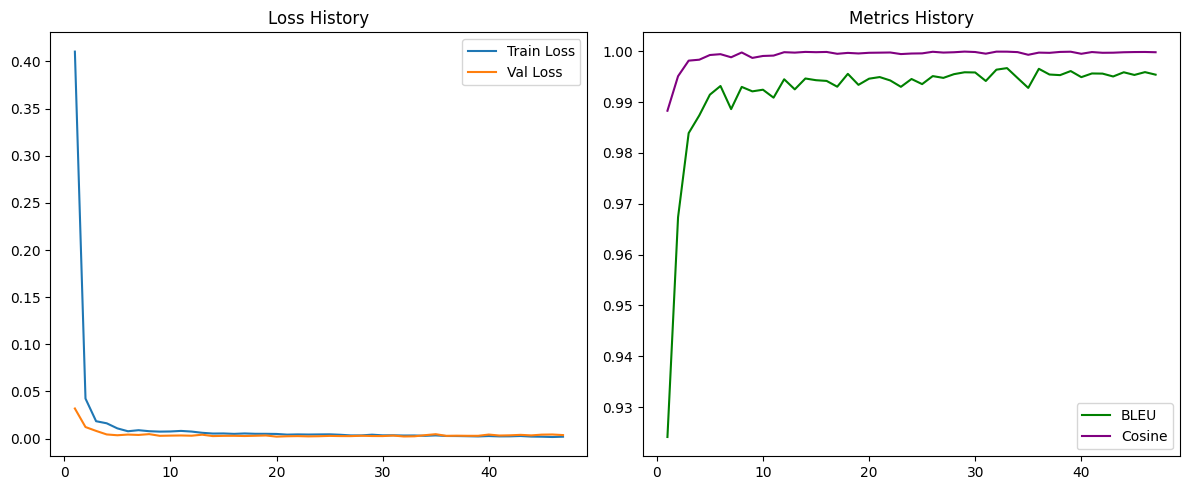

(None, None)

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 128
BATCH_SIZE = 48
EPOCHS = 47
NUMBER_OF_BEAMS = 1
LEARNING_RATE = 5e-5
TRAIN_TEST_RATO = 0.9
PATIENCE_LR_ROP = 160
FACTOR_LR_ROP = 0.1
NUMBER_OF_AUGMENTATIONS = 30
REPITION_PENALTY =1.4
WEIGHT_DECAY = 0.000390625 # <--- NEW HYPERPARAMETER ADDED HERE
ADAM_EPSILON = 1e-8  # <--- NEW HYPERPARAMETER CHANGED HERE (default is 1e-8)
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Clean the inputs: Convert multiline strings to space-separated strings
# Note: This assumes 'shuffled_sentences_raw' and 'merged_ground_truth_sentences' exist in the environment
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

# ---> HYPERPARAMETER MODIFICATION APPLIED HERE <---
# Changed num_augmentations default from 10 to 5
def augment_data(ground_truth_list, num_augmentations=5):
    inputs = []
    targets = []
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
    return inputs, targets

# Changed num_augmentations argument from 10 to 5 to reduce execution time
aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=NUMBER_OF_AUGMENTATIONS)
# -------------------------------------------------

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])
        source_tok = self.tokenizer(source, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        target_tok = self.tokenizer(target, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {'input_ids': source_tok['input_ids'].flatten(), 'attention_mask': source_tok['attention_mask'].flatten(), 'labels': labels}

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_size = int(TRAIN_TEST_RATO * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

# ---> HYPERPARAMETER MODIFICATION APPLIED HERE <---
# ADDED the betas hyperparameter to AdamW (default is (0.9, 0.999), changed to (0.95, 0.999))
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, eps=ADAM_EPSILON, betas=(0.996, 0.999))

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)
    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP (DYNAMIC LR & BEST TRACKING)
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': [], 'lr': []}

# ---------------------------------------------------------
# MODIFIED HYPERPARAMETER: factor (Learning Rate Scheduler)
# Changed factor from 0.5 to 0.2. This won't impact execution time.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=FACTOR_LR_ROP, patience=PATIENCE_LR_ROP)
# ---------------------------------------------------------

best_val_loss = float('inf')
best_epoch = -1
best_lr_at_best_epoch = LEARNING_RATE
best_metrics = {}

print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in progress_bar:
        input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss, predictions, references = 0, [] , []
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                max_length=MAX_LEN, 
                num_beams = NUMBER_OF_BEAMS, # Set to 1 for faster generation (Greedy Decoding)
                repetition_penalty = REPITION_PENALTY # <--- NEW HYPERPARAMETER ADDED HERE (Does not affect execution time)
            )
            
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    current_lr = optimizer.param_groups[0]['lr']

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_lr_at_best_epoch = current_lr
        best_metrics = {'Val Loss': avg_val_loss, 'BLEU': bleu, 'Cosine Similarity': cosine}
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"--> New best model found! Saving to {SAVE_DIR}...")

    # Update scheduler
    scheduler.step(avg_val_loss)
    
    history['epoch'].append(epoch + 1); history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss); history['bleu'].append(bleu)
    history['cosine'].append(cosine); history['lr'].append(current_lr)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f} | LR: {current_lr}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
print("\n" + "="*50)
print("🏆 TRAINING COMPLETED - SUMMARY OF BEST EPOCH 🏆")
print("="*50)
if best_epoch != -1:
    print(f"Best Epoch            : {best_epoch}")
    print(f"Learning Rate at Best : {best_lr_at_best_epoch:.2e}")
    print("Metrics at Best Epoch :")
    for m_name, m_val in best_metrics.items():
        print(f"  - {m_name}: {m_val:.6f}")
else:
    print("No best epoch found (training may have been too short).")
print("="*50)

# Load best model for plotting/samples
if os.path.exists(SAVE_DIR):
    model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)
    
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss')
plt.title('Loss History'), plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', color='green')
if calc_cosine: 
    plt.plot(history['epoch'], history['cosine'], label='Cosine', color='purple')
plt.title('Metrics History'), plt.legend()
plt.tight_layout(), plt.show()